# Load Data Set

In [48]:
#importing/memasukkan package untuk alat bantu memproses data
import pandas as pd
import numpy as np
from scipy.stats import stats
import seaborn as sns
import warnings
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
warnings.simplefilter(action='ignore',category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option('display.max_columns',50)

# Membaca dan menampilkan dataset yang akan diproses
# df = pd.read_csv(r'C:\Users\ASUS\Downloads\latihan Netflix\whoop_fitness_dataset_100k.csv')
path = (r'C:\Users\ASUS\Downloads\latihan Netflix\whoop_fitness_dataset_100k.csv')
df = pd.read_csv(path)
df.head(5)

,user_id,date,day_of_week,age,gender,weight_kg,height_cm,fitness_level,primary_sport,recovery_score,day_strain,sleep_hours,sleep_efficiency,sleep_performance,light_sleep_hours,rem_sleep_hours,deep_sleep_hours,wake_ups,time_to_fall_asleep_min,hrv,resting_heart_rate,hrv_baseline,rhr_baseline,respiratory_rate,skin_temp_deviation,calories_burned,workout_completed,activity_type,activity_duration_min,activity_strain,avg_heart_rate,max_heart_rate,activity_calories,hr_zone_1_min,hr_zone_2_min,hr_zone_3_min,hr_zone_4_min,hr_zone_5_min,workout_time_of_day
0,USER_00001,2023-01-01,Sunday,56,Female,53.9,167.2,Beginner,Weight Training,57.8,7.33,6.13,72.3,100.0,3.68,1.23,1.22,1,17.0,118.3,61.5,101,59,11.1,0.30,2849.0,0,Rest Day,0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,USER_00001,2023-01-02,Monday,56,Female,53.9,167.2,Beginner,Weight Training,62.6,10.38,6.33,78.3,100.0,3.97,1.41,0.95,1,5.8,105.7,57.5,101,59,15.9,-0.37,3201.0,1,Weight Training,62,7.47,121.2,137.6,371.0,11.9,18.0,15.9,11.6,4.6,Evening
2,USER_00001,2023-01-03,Tuesday,56,Female,53.9,167.2,Beginner,Weight Training,81.5,7.16,6.17,78.8,100.0,3.70,1.52,0.95,0,5.0,95.3,56.7,101,59,14.9,-0.67,2697.0,0,Rest Day,0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,USER_00001,2023-01-04,Wednesday,56,Female,53.9,167.2,Beginner,Weight Training,55.0,16.47,6.49,80.3,100.0,3.94,1.55,1.00,0,5.0,76.2,60.8,101,59,16.7,0.49,4175.0,0,Rest Day,0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,USER_00001,2023-01-05,Thursday,56,Female,53.9,167.2,Beginner,Weight Training,62.5,16.67,6.67,73.0,100.0,4.14,1.49,1.04,0,5.0,94.4,65.6,101,59,16.7,1.69,4116.0,1,Weight Training,51,15.27,136.4,152.8,623.0,3.7,6.0,13.7,18.6,9.0,Evening


### Data Dictionary

| Nama Kolom | Deskripsi |
|---|---|
| user_id | Identitas pengguna anonim yang unik |
| date | Tanggal pengukuran (YYYY-MM-DD) |
| day_of_week | Nama hari (Senin–Minggu) |
| age | Usia pengguna (18–64 tahun) |
| gender | Jenis kelamin (Laki-laki atau Perempuan) |
| weight_kg | Berat badan dalam kilogram |
| height_cm | Tinggi badan dalam sentimeter |
| fitness_level | Tingkat kebugaran: Beginner, Intermediate, Advanced, atau Elite |
| primary_sport | Olahraga atau aktivitas utama pengguna |
| recovery_score | Persentase tingkat pemulihan tubuh secara keseluruhan (0–100%) |
| day_strain | Skor beban latihan harian (0–21) yang mengukur beban kardiovaskular dari seluruh aktivitas |
| sleep_hours | Total durasi tidur dalam jam |
| sleep_efficiency | Persentase waktu di tempat tidur yang benar-benar digunakan untuk tidur (0–100%) |
| sleep_performance | Skor kualitas tidur secara keseluruhan (0–100%) |
| light_sleep_hours | Durasi tahap tidur ringan |
| rem_sleep_hours | Durasi tahap tidur REM (Rapid Eye Movement) |
| deep_sleep_hours | Durasi tahap tidur dalam (deep sleep) |
| wake_ups | Jumlah terbangun selama malam hari |
| time_to_fall_asleep_min | Waktu yang dibutuhkan untuk tertidur (menit) |
| hrv | Variabilitas detak jantung (Heart Rate Variability) dalam milidetik |
| resting_heart_rate | Detak jantung saat istirahat (beats per minute / bpm) |
| hrv_baseline | Nilai baseline HRV pengguna untuk perbandingan |
| rhr_baseline | Nilai baseline detak jantung istirahat pengguna |
| respiratory_rate | Jumlah napas per menit saat tidur |
| skin_temp_deviation | Perbedaan suhu kulit dibanding baseline (°C) |
| calories_burned | Total kalori yang terbakar dalam satu hari |
| workout_completed | Status apakah workout dilakukan (1 = ya, 0 = hari istirahat) |
| activity_type | Jenis aktivitas atau "Rest Day" jika tidak ada aktivitas |
| activity_duration_min | Durasi aktivitas dalam menit (0 jika hari istirahat) |
| activity_strain | Skor beban dari aktivitas tersebut |
| avg_heart_rate | Detak jantung rata-rata selama aktivitas (bpm) |
| max_heart_rate | Detak jantung maksimum yang dicapai selama aktivitas (bpm) |
| activity_calories | Kalori yang terbakar selama aktivitas |
| hr_zone_1_min | Durasi di Zona Detak Jantung 1 (50–60% max HR, sangat ringan) |
| hr_zone_2_min | Durasi di Zona Detak Jantung 2 (60–70% max HR, ringan) |
| hr_zone_3_min | Durasi di Zona Detak Jantung 3 (70–80% max HR, sedang) |
| hr_zone_4_min | Durasi di Zona Detak Jantung 4 (80–90% max HR, berat) |
| hr_zone_5_min | Durasi di Zona Detak Jantung 5 (90–100% max HR, maksimal) |
| workout_time_of_day | Waktu aktivitas dilakukan: Morning, Afternoon, Evening, atau N/A |

In [49]:
df.shape

(100000, 39)

# Data Inspection

In [50]:
df.head()

,user_id,date,day_of_week,age,gender,weight_kg,height_cm,fitness_level,primary_sport,recovery_score,day_strain,sleep_hours,sleep_efficiency,sleep_performance,light_sleep_hours,rem_sleep_hours,deep_sleep_hours,wake_ups,time_to_fall_asleep_min,hrv,resting_heart_rate,hrv_baseline,rhr_baseline,respiratory_rate,skin_temp_deviation,calories_burned,workout_completed,activity_type,activity_duration_min,activity_strain,avg_heart_rate,max_heart_rate,activity_calories,hr_zone_1_min,hr_zone_2_min,hr_zone_3_min,hr_zone_4_min,hr_zone_5_min,workout_time_of_day
0,USER_00001,2023-01-01,Sunday,56,Female,53.9,167.2,Beginner,Weight Training,57.8,7.33,6.13,72.3,100.0,3.68,1.23,1.22,1,17.0,118.3,61.5,101,59,11.1,0.30,2849.0,0,Rest Day,0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,USER_00001,2023-01-02,Monday,56,Female,53.9,167.2,Beginner,Weight Training,62.6,10.38,6.33,78.3,100.0,3.97,1.41,0.95,1,5.8,105.7,57.5,101,59,15.9,-0.37,3201.0,1,Weight Training,62,7.47,121.2,137.6,371.0,11.9,18.0,15.9,11.6,4.6,Evening
2,USER_00001,2023-01-03,Tuesday,56,Female,53.9,167.2,Beginner,Weight Training,81.5,7.16,6.17,78.8,100.0,3.70,1.52,0.95,0,5.0,95.3,56.7,101,59,14.9,-0.67,2697.0,0,Rest Day,0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,USER_00001,2023-01-04,Wednesday,56,Female,53.9,167.2,Beginner,Weight Training,55.0,16.47,6.49,80.3,100.0,3.94,1.55,1.00,0,5.0,76.2,60.8,101,59,16.7,0.49,4175.0,0,Rest Day,0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,USER_00001,2023-01-05,Thursday,56,Female,53.9,167.2,Beginner,Weight Training,62.5,16.67,6.67,73.0,100.0,4.14,1.49,1.04,0,5.0,94.4,65.6,101,59,16.7,1.69,4116.0,1,Weight Training,51,15.27,136.4,152.8,623.0,3.7,6.0,13.7,18.6,9.0,Evening


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 39 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   user_id                  100000 non-null  object 
 1   date                     100000 non-null  object 
 2   day_of_week              100000 non-null  object 
 3   age                      100000 non-null  int64  
 4   gender                   100000 non-null  object 
 5   weight_kg                100000 non-null  float64
 6   height_cm                100000 non-null  float64
 7   fitness_level            100000 non-null  object 
 8   primary_sport            100000 non-null  object 
 9   recovery_score           100000 non-null  float64
 10  day_strain               100000 non-null  float64
 11  sleep_hours              100000 non-null  float64
 12  sleep_efficiency         100000 non-null  float64
 13  sleep_performance        100000 non-null  float64
 14  light

In [52]:
df.columns

Index(['user_id', 'date', 'day_of_week', 'age', 'gender', 'weight_kg',
       'height_cm', 'fitness_level', 'primary_sport', 'recovery_score',
       'day_strain', 'sleep_hours', 'sleep_efficiency', 'sleep_performance',
       'light_sleep_hours', 'rem_sleep_hours', 'deep_sleep_hours', 'wake_ups',
       'time_to_fall_asleep_min', 'hrv', 'resting_heart_rate', 'hrv_baseline',
       'rhr_baseline', 'respiratory_rate', 'skin_temp_deviation',
       'calories_burned', 'workout_completed', 'activity_type',
       'activity_duration_min', 'activity_strain', 'avg_heart_rate',
       'max_heart_rate', 'activity_calories', 'hr_zone_1_min', 'hr_zone_2_min',
       'hr_zone_3_min', 'hr_zone_4_min', 'hr_zone_5_min',
       'workout_time_of_day'],
      dtype='object')

In [53]:
df.describe()

,age,weight_kg,height_cm,recovery_score,day_strain,sleep_hours,sleep_efficiency,sleep_performance,light_sleep_hours,rem_sleep_hours,deep_sleep_hours,wake_ups,time_to_fall_asleep_min,hrv,resting_heart_rate,hrv_baseline,rhr_baseline,respiratory_rate,skin_temp_deviation,calories_burned,workout_completed,activity_duration_min,activity_strain,avg_heart_rate,max_heart_rate,activity_calories,hr_zone_1_min,hr_zone_2_min,hr_zone_3_min,hr_zone_4_min,hr_zone_5_min
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.642950,72.707693,171.754403,65.130442,9.911999,7.296272,82.883422,100.0,4.378101,1.641338,1.276817,0.338920,5.577995,73.235746,57.627420,73.356860,59.163250,15.993832,0.003286,3286.646650,0.540100,27.646820,5.740622,74.555414,84.158187,241.158940,4.492818,6.772501,7.270141,6.550316,2.607983
std,13.257307,13.896367,9.337338,17.698584,4.489623,0.972416,10.222554,0.0,0.603068,0.242734,0.200364,0.618803,2.183646,28.477633,9.268706,25.040026,8.392176,2.002110,0.500186,702.036628,0.498392,29.018375,6.442949,69.630320,78.495935,299.910276,6.081894,7.527003,8.371101,8.492293,3.829844
min,18.000000,38.100000,149.400000,5.000000,0.000000,4.000000,50.000000,100.0,2.240000,0.810000,0.600000,0.000000,5.000000,20.000000,40.000000,30.000000,45.000000,7.500000,-2.390000,871.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,62.900000,165.300000,52.400000,6.650000,6.650000,76.500000,100.0,3.980000,1.480000,1.140000,0.000000,5.000000,51.500000,50.300000,54.000000,52.000000,14.600000,-0.340000,2784.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,41.000000,72.100000,171.500000,64.500000,9.530000,7.460000,85.000000,100.0,4.460000,1.660000,1.280000,0.000000,5.000000,72.600000,57.100000,73.000000,59.000000,16.000000,0.010000,3236.000000,1.000000,27.000000,2.830000,115.900000,132.400000,84.000000,1.400000,5.000000,5.000000,1.200000,0.000000
75%,53.000000,82.000000,178.900000,77.400000,12.890000,8.030000,90.500000,100.0,4.820000,1.820000,1.420000,1.000000,5.000000,94.500000,64.800000,93.000000,66.000000,17.300000,0.340000,3754.000000,1.000000,51.000000,11.980000,138.400000,156.200000,455.000000,7.300000,12.400000,13.600000,12.400000,4.600000
max,64.000000,115.000000,195.800000,100.000000,21.000000,10.000000,100.000000,100.0,6.210000,2.430000,1.930000,7.000000,51.300000,150.000000,85.500000,119.000000,74.000000,24.500000,2.020000,5695.000000,1.000000,119.000000,21.000000,181.800000,202.000000,1831.000000,45.500000,46.500000,42.900000,46.600000,29.500000


## Check Data Types

In [54]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object','category']).columns

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: Index(['age', 'weight_kg', 'height_cm', 'recovery_score', 'day_strain',
       'sleep_hours', 'sleep_efficiency', 'sleep_performance',
       'light_sleep_hours', 'rem_sleep_hours', 'deep_sleep_hours', 'wake_ups',
       'time_to_fall_asleep_min', 'hrv', 'resting_heart_rate', 'hrv_baseline',
       'rhr_baseline', 'respiratory_rate', 'skin_temp_deviation',
       'calories_burned', 'workout_completed', 'activity_duration_min',
       'activity_strain', 'avg_heart_rate', 'max_heart_rate',
       'activity_calories', 'hr_zone_1_min', 'hr_zone_2_min', 'hr_zone_3_min',
       'hr_zone_4_min', 'hr_zone_5_min'],
      dtype='object')
Categorical columns: Index(['user_id', 'date', 'day_of_week', 'gender', 'fitness_level',
       'primary_sport', 'activity_type', 'workout_time_of_day'],
      dtype='object')


In [55]:
pd.set_option('display.max_colwidth', None)
unique_summary = pd.DataFrame({
    'n_unique': df.nunique(),
    'unique_values': df.apply(lambda x: x.unique())
})

unique_summary

,n_unique,unique_values
user_id,286,"[USER_00001, USER_00002, USER_00003, USER_00004, USER_00005, USER_00006, USER_00007, USER_00008, USER_00009, USER_00010, USER_00011, USER_00012, USER_00013, USER_00014, USER_00015, USER_00016, USER_00017, USER_00018, USER_00019, USER_00020, USER_00021, USER_00022, USER_00023, USER_00024, USER_00025, USER_00026, USER_00027, USER_00028, USER_00029, USER_00030, USER_00031, USER_00032, USER_00033, USER_00034, USER_00035, USER_00036, USER_00037, USER_00038, USER_00039, USER_00040, USER_00041, USER_00042, USER_00043, USER_00044, USER_00045, USER_00046, USER_00047, USER_00048, USER_00049, USER_00050, USER_00051, USER_00052, USER_00053, USER_00054, USER_00055, USER_00056, USER_00057, USER_00058, USER_00059, USER_00060, USER_00061, USER_00062, USER_00063, USER_00064, USER_00065, USER_00066, USER_00067, USER_00068, USER_00069, USER_00070, USER_00071, USER_00072, USER_00073, USER_00074, USER_00075, USER_00076, USER_00077, USER_00078, USER_00079, USER_00080, USER_00081, USER_00082, USER_00083, USER_00084, USER_00085, USER_00086, USER_00087, USER_00088, USER_00089, USER_00090, USER_00091, USER_00092, USER_00093, USER_00094, USER_00095, USER_00096, USER_00097, USER_00098, USER_00099, USER_00100, ...]"
date,399,"[2023-01-01, 2023-01-02, 2023-01-03, 2023-01-04, 2023-01-05, 2023-01-06, 2023-01-07, 2023-01-08, 2023-01-09, 2023-01-10, 2023-01-11, 2023-01-12, 2023-01-13, 2023-01-14, 2023-01-15, 2023-01-16, 2023-01-17, 2023-01-18, 2023-01-19, 2023-01-20, 2023-01-21, 2023-01-22, 2023-01-23, 2023-01-24, 2023-01-25, 2023-01-26, 2023-01-27, 2023-01-28, 2023-01-29, 2023-01-30, 2023-01-31, 2023-02-01, 2023-02-02, 2023-02-03, 2023-02-04, 2023-02-05, 2023-02-06, 2023-02-07, 2023-02-08, 2023-02-09, 2023-02-10, 2023-02-11, 2023-02-12, 2023-02-13, 2023-02-14, 2023-02-15, 2023-02-16, 2023-02-17, 2023-02-18, 2023-02-19, 2023-02-20, 2023-02-21, 2023-02-22, 2023-02-23, 2023-02-24, 2023-02-25, 2023-02-26, 2023-02-27, 2023-02-28, 2023-03-01, 2023-03-02, 2023-03-03, 2023-03-04, 2023-03-05, 2023-03-06, 2023-03-07, 2023-03-08, 2023-03-09, 2023-03-10, 2023-03-11, 2023-03-12, 2023-03-13, 2023-03-14, 2023-03-15, 2023-03-16, 2023-03-17, 2023-03-18, 2023-03-19, 2023-03-20, 2023-03-21, 2023-03-22, 2023-03-23, 2023-03-24, 2023-03-25, 2023-03-26, 2023-03-27, 2023-03-28, 2023-03-29, 2023-03-30, 2023-03-31, 2023-04-01, 2023-04-02, 2023-04-03, 2023-04-04, 2023-04-05, 2023-04-06, 2023-04-07, 2023-04-08, 2023-04-09, 2023-04-10, ...]"
day_of_week,7,"[Sunday, Monday, Tuesday, Wednesday, Thursday, Friday, Saturday]"
age,47,"[56, 43, 36, 47, 55, 29, 61, 63, 45, 24, 20, 38, 41, 54, 31, 48, 40, 62, 50, 53, 58, 32, 26, 52, 28, 23, 33, 34, 27, 35, 64, 39, 25, 37, 42, 44, 51, 60, 57, 19, 21, 59, 30, 46, 18, 49, 22]"
gender,2,"[Female, Male]"
weight_kg,224,"[53.9, 88.8, 63.0, 75.2, 77.6, 57.5, 77.5, 66.4, 71.4, 58.3, 58.0, 70.8, 99.4, 85.0, 53.6, 62.7, 68.5, 63.2, 77.7, 77.2, 82.2, 51.6, 64.3, 45.2, 85.2, 67.2, 64.5, 63.5, 62.0, 64.1, 95.1, 94.4, 86.5, 84.3, 58.4, 75.7, 70.7, 89.9, 65.2, 101.8, 53.5, 95.9, 71.5, 46.7, 49.6, 61.0, 73.7, 86.3, 49.9, 54.4, 89.1, 59.3, 61.3, 49.8, 68.6, 72.0, 48.6, 77.1, 76.8, 97.0, 43.6, 78.8, 93.7, 83.9, 79.1, 75.0, 75.9, 64.0, 58.2, 67.8, 47.6, 88.6, 89.8, 79.4, 61.6, 67.3, 90.9, 73.4, 78.7, 71.9, 70.0, 100.0, 112.0, 38.1, 65.8, 70.3, 86.9, 57.4, 88.3, 72.1, 78.9, 72.4, 65.6, 89.0, 84.9, 96.4, 68.0, 83.5, 78.3, 76.3, ...]"
height_cm,188,"[167.2, 184.0, 166.5, 169.2, 151.3, 189.8, 159.9, 159.7, 152.8, 160.5, 169.6, 162.1, 168.8, 178.7, 163.7, 164.5, 166.7, 186.5, 181.7, 187.5, 156.5, 173.9, 166.6, 181.0, 172.3, 167.9, 175.0, 172.2, 157.8, 180.5, 171.5, 176.4, 169.0, 160.4, 173.3, 168.7, 184.6, 182.5, 187.1, 180.9, 161.2, 151.0, 173.5, 162.4, 164.0, 176.7, 158.7, 167.0, 182.1, 171.7, 177.2, 157.5, 180.4, 157.3, 163.8, 149.4, 154.4, 186.3, 178.4, 175.4, 159.3, 168.2, 177.1, 176.3, 190.5, 162.5, 166.3, 161.6, 183.9, 166.8, 176.6, 173.0, 168.1, 179.3, 171.6, 182.4, 185.8, 165.9, 168.4, 166.4, 182.2, 185.1, 179.1, 180.0, 172.1

In [56]:
df['sleep_performance'].value_counts()

sleep_performance
100.0    100000
Name: count, dtype: int64

## Missing Values

In [57]:
missing = df.isnull().sum()
missing[missing > 0]

workout_time_of_day    45990
dtype: int64

## Dupicated values

In [58]:
print(df.duplicated().sum())

0


## Check Outliers

In [59]:
df.describe(percentiles=[.01,.99])

,age,weight_kg,height_cm,recovery_score,day_strain,sleep_hours,sleep_efficiency,sleep_performance,light_sleep_hours,rem_sleep_hours,deep_sleep_hours,wake_ups,time_to_fall_asleep_min,hrv,resting_heart_rate,hrv_baseline,rhr_baseline,respiratory_rate,skin_temp_deviation,calories_burned,workout_completed,activity_duration_min,activity_strain,avg_heart_rate,max_heart_rate,activity_calories,hr_zone_1_min,hr_zone_2_min,hr_zone_3_min,hr_zone_4_min,hr_zone_5_min
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.642950,72.707693,171.754403,65.130442,9.911999,7.296272,82.883422,100.0,4.378101,1.641338,1.276817,0.338920,5.577995,73.235746,57.627420,73.356860,59.163250,15.993832,0.003286,3286.646650,0.540100,27.646820,5.740622,74.555414,84.158187,241.158940,4.492818,6.772501,7.270141,6.550316,2.607983
std,13.257307,13.896367,9.337338,17.698584,4.489623,0.972416,10.222554,0.0,0.603068,0.242734,0.200364,0.618803,2.183646,28.477633,9.268706,25.040026,8.392176,2.002110,0.500186,702.036628,0.498392,29.018375,6.442949,69.630320,78.495935,299.910276,6.081894,7.527003,8.371101,8.492293,3.829844
min,18.000000,38.100000,149.400000,5.000000,0.000000,4.000000,50.000000,100.0,2.240000,0.810000,0.600000,0.000000,5.000000,20.000000,40.000000,30.000000,45.000000,7.500000,-2.390000,871.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1%,19.000000,44.900000,151.300000,27.500000,0.650000,4.750000,54.400000,100.0,2.830000,1.050000,0.800000,0.000000,5.000000,20.000000,40.000000,30.000000,45.000000,11.300000,-1.160000,1846.980000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,41.000000,72.100000,171.500000,64.500000,9.530000,7.460000,85.000000,100.0,4.460000,1.660000,1.280000,0.000000,5.000000,72.600000,57.100000,73.000000,59.000000,16.000000,0.010000,3236.000000,1.000000,27.000000,2.830000,115.900000,132.400000,84.000000,1.400000,5.000000,5.000000,1.200000,0.000000
99%,64.000000,105.200000,192.400000,100.000000,21.000000,9.030000,100.000000,100.0,5.520000,2.130000,1.700000,2.000000,16.000000,134.500000,77.400000,119.000000,74.000000,20.600000,1.160000,4984.000000,1.000000,104.000000,19.080000,167.600000,187.200000,1107.000000,22.600000,25.100000,31.100000,31.400000,15.500000
max,64.000000,115.000000,195.800000,100.000000,21.000000,10.000000,100.000000,100.0,6.210000,2.430000,1.930000,7.000000,51.300000,150.000000,85.500000,119.000000,74.000000,24.500000,2.020000,5695.000000,1.000000,119.000000,21.000000,181.800000,202.000000,1831.000000,45.500000,46.500000,42.900000,46.600000,29.500000


In [60]:
outliers = df[
    (df['calories_burned'] > 6000) |
    (df['max_heart_rate'] > 210) |
    (df['hrv'] > 250)
]
outliers

,user_id,date,day_of_week,age,gender,weight_kg,height_cm,fitness_level,primary_sport,recovery_score,day_strain,sleep_hours,sleep_efficiency,sleep_performance,light_sleep_hours,rem_sleep_hours,deep_sleep_hours,wake_ups,time_to_fall_asleep_min,hrv,resting_heart_rate,hrv_baseline,rhr_baseline,respiratory_rate,skin_temp_deviation,calories_burned,workout_completed,activity_type,activity_duration_min,activity_strain,avg_heart_rate,max_heart_rate,activity_calories,hr_zone_1_min,hr_zone_2_min,hr_zone_3_min,hr_zone_4_min,hr_zone_5_min,workout_time_of_day


In [61]:
num_cols = df.select_dtypes(include="number").columns

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_summary = pd.DataFrame({
    "Jumlah Outlier": ((df[num_cols] < lower) | (df[num_cols] > upper)).sum(),
    "Persentase Outlier (%)": (
        ((df[num_cols] < lower) | (df[num_cols] > upper)).sum() / len(df) * 100
    ).round(2),
    "Nilai Skewness": df[num_cols].skew()
})

outlier_summary[outlier_summary["Persentase Outlier (%)"]> 0].sort_values(by="Persentase Outlier (%)",ascending=False)

,Jumlah Outlier,Persentase Outlier (%),Nilai Skewness
time_to_fall_asleep_min,14494,14.49,6.188527
hr_zone_1_min,4882,4.88,1.397783
hr_zone_5_min,3857,3.86,1.687714
sleep_efficiency,1266,1.27,-0.745751
hr_zone_4_min,1087,1.09,1.163430
wake_ups,938,0.94,2.014148
activity_calories,808,0.81,1.105670
respiratory_rate,712,0.71,-0.013919
weight_kg,701,0.70,0.257742
sleep_hours,648,0.65,-0.577616


# Handling Data Issues

## Change Date time format

In [62]:
df['date'] = pd.to_datetime(df['date'])

df.head()

,user_id,date,day_of_week,age,gender,weight_kg,height_cm,fitness_level,primary_sport,recovery_score,day_strain,sleep_hours,sleep_efficiency,sleep_performance,light_sleep_hours,rem_sleep_hours,deep_sleep_hours,wake_ups,time_to_fall_asleep_min,hrv,resting_heart_rate,hrv_baseline,rhr_baseline,respiratory_rate,skin_temp_deviation,calories_burned,workout_completed,activity_type,activity_duration_min,activity_strain,avg_heart_rate,max_heart_rate,activity_calories,hr_zone_1_min,hr_zone_2_min,hr_zone_3_min,hr_zone_4_min,hr_zone_5_min,workout_time_of_day
0,USER_00001,2023-01-01,Sunday,56,Female,53.9,167.2,Beginner,Weight Training,57.8,7.33,6.13,72.3,100.0,3.68,1.23,1.22,1,17.0,118.3,61.5,101,59,11.1,0.30,2849.0,0,Rest Day,0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,USER_00001,2023-01-02,Monday,56,Female,53.9,167.2,Beginner,Weight Training,62.6,10.38,6.33,78.3,100.0,3.97,1.41,0.95,1,5.8,105.7,57.5,101,59,15.9,-0.37,3201.0,1,Weight Training,62,7.47,121.2,137.6,371.0,11.9,18.0,15.9,11.6,4.6,Evening
2,USER_00001,2023-01-03,Tuesday,56,Female,53.9,167.2,Beginner,Weight Training,81.5,7.16,6.17,78.8,100.0,3.70,1.52,0.95,0,5.0,95.3,56.7,101,59,14.9,-0.67,2697.0,0,Rest Day,0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,USER_00001,2023-01-04,Wednesday,56,Female,53.9,167.2,Beginner,Weight Training,55.0,16.47,6.49,80.3,100.0,3.94,1.55,1.00,0,5.0,76.2,60.8,101,59,16.7,0.49,4175.0,0,Rest Day,0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,USER_00001,2023-01-05,Thursday,56,Female,53.9,167.2,Beginner,Weight Training,62.5,16.67,6.67,73.0,100.0,4.14,1.49,1.04,0,5.0,94.4,65.6,101,59,16.7,1.69,4116.0,1,Weight Training,51,15.27,136.4,152.8,623.0,3.7,6.0,13.7,18.6,9.0,Evening


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 39 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   user_id                  100000 non-null  object        
 1   date                     100000 non-null  datetime64[ns]
 2   day_of_week              100000 non-null  object        
 3   age                      100000 non-null  int64         
 4   gender                   100000 non-null  object        
 5   weight_kg                100000 non-null  float64       
 6   height_cm                100000 non-null  float64       
 7   fitness_level            100000 non-null  object        
 8   primary_sport            100000 non-null  object        
 9   recovery_score           100000 non-null  float64       
 10  day_strain               100000 non-null  float64       
 11  sleep_hours              100000 non-null  float64       
 12  sleep_efficiency 

## Handling Missing Value

In [64]:
df['workout_time_of_day'] = df['workout_time_of_day'].fillna('No Workout')
df.head()

,user_id,date,day_of_week,age,gender,weight_kg,height_cm,fitness_level,primary_sport,recovery_score,day_strain,sleep_hours,sleep_efficiency,sleep_performance,light_sleep_hours,rem_sleep_hours,deep_sleep_hours,wake_ups,time_to_fall_asleep_min,hrv,resting_heart_rate,hrv_baseline,rhr_baseline,respiratory_rate,skin_temp_deviation,calories_burned,workout_completed,activity_type,activity_duration_min,activity_strain,avg_heart_rate,max_heart_rate,activity_calories,hr_zone_1_min,hr_zone_2_min,hr_zone_3_min,hr_zone_4_min,hr_zone_5_min,workout_time_of_day
0,USER_00001,2023-01-01,Sunday,56,Female,53.9,167.2,Beginner,Weight Training,57.8,7.33,6.13,72.3,100.0,3.68,1.23,1.22,1,17.0,118.3,61.5,101,59,11.1,0.30,2849.0,0,Rest Day,0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No Workout
1,USER_00001,2023-01-02,Monday,56,Female,53.9,167.2,Beginner,Weight Training,62.6,10.38,6.33,78.3,100.0,3.97,1.41,0.95,1,5.8,105.7,57.5,101,59,15.9,-0.37,3201.0,1,Weight Training,62,7.47,121.2,137.6,371.0,11.9,18.0,15.9,11.6,4.6,Evening
2,USER_00001,2023-01-03,Tuesday,56,Female,53.9,167.2,Beginner,Weight Training,81.5,7.16,6.17,78.8,100.0,3.70,1.52,0.95,0,5.0,95.3,56.7,101,59,14.9,-0.67,2697.0,0,Rest Day,0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No Workout
3,USER_00001,2023-01-04,Wednesday,56,Female,53.9,167.2,Beginner,Weight Training,55.0,16.47,6.49,80.3,100.0,3.94,1.55,1.00,0,5.0,76.2,60.8,101,59,16.7,0.49,4175.0,0,Rest Day,0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,No Workout
4,USER_00001,2023-01-05,Thursday,56,Female,53.9,167.2,Beginner,Weight Training,62.5,16.67,6.67,73.0,100.0,4.14,1.49,1.04,0,5.0,94.4,65.6,101,59,16.7,1.69,4116.0,1,Weight Training,51,15.27,136.4,152.8,623.0,3.7,6.0,13.7,18.6,9.0,Evening


In [65]:
df['workout_time_of_day'].value_counts()

workout_time_of_day
No Workout    45990
Morning       21505
Afternoon     16258
Evening       16247
Name: count, dtype: int64

## Handling Outliers


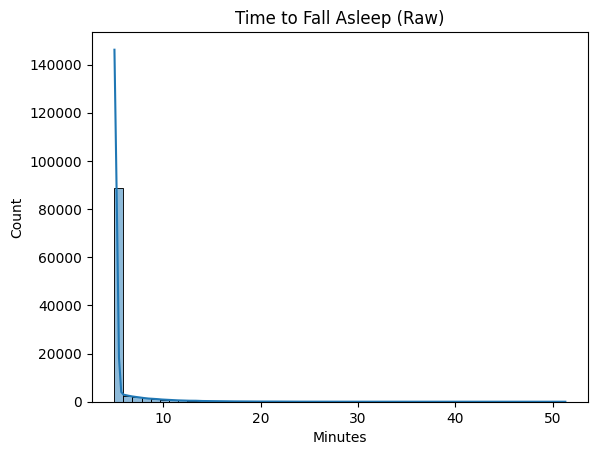

Skewness: 6.188526634616


count    100000.000000
mean          5.577995
std           2.183646
min           5.000000
25%           5.000000
50%           5.000000
75%           5.000000
max          51.300000
Name: time_to_fall_asleep_min, dtype: float64

In [66]:
sns.histplot(df['time_to_fall_asleep_min'], bins=50, kde=True)
plt.title("Time to Fall Asleep (Raw)")
plt.xlabel("Minutes")
plt.ylabel("Count")
plt.show()

print("Skewness:", df['time_to_fall_asleep_min'].skew())
df['time_to_fall_asleep_min'].describe()

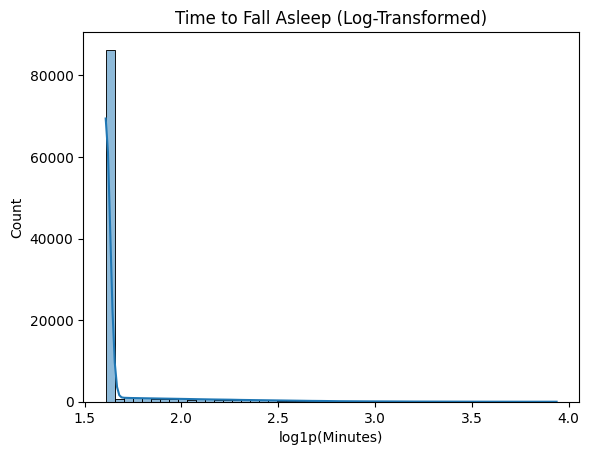

Skewness (log): 3.9205502908884684


count    100000.000000
mean          1.682075
std           0.229774
min           1.609438
25%           1.609438
50%           1.609438
75%           1.609438
max           3.937691
Name: sleep_latency_log, dtype: float64

In [67]:
df['sleep_latency_log'] = np.log(df['time_to_fall_asleep_min'])

sns.histplot(df['sleep_latency_log'], bins=50, kde=True)
plt.title("Time to Fall Asleep (Log-Transformed)")
plt.xlabel("log1p(Minutes)")
plt.ylabel("Count")
plt.show()

print("Skewness (log):", df['sleep_latency_log'].skew())
df['sleep_latency_log'].describe()

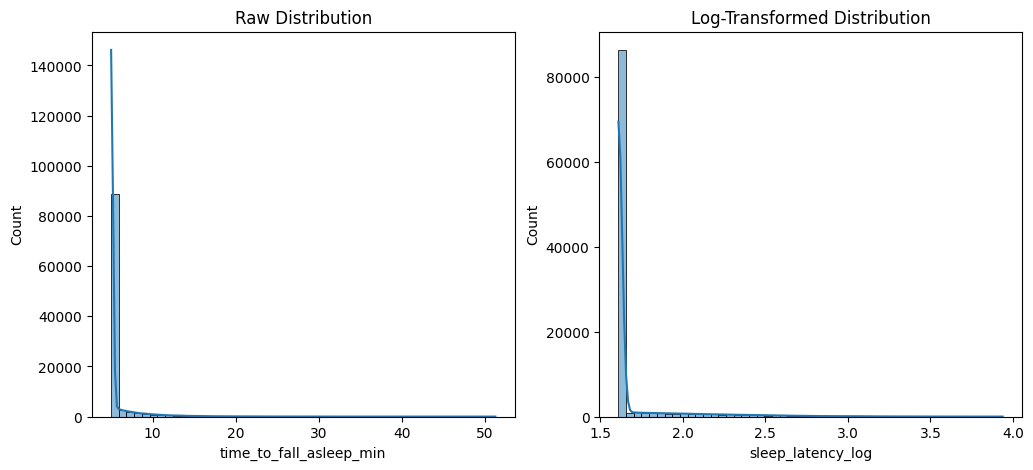

In [68]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['time_to_fall_asleep_min'], bins=50, kde=True, ax=ax[0])
ax[0].set_title("Raw Distribution")

sns.histplot(df['sleep_latency_log'], bins=50, kde=True, ax=ax[1])
ax[1].set_title("Log-Transformed Distribution")

plt.show()

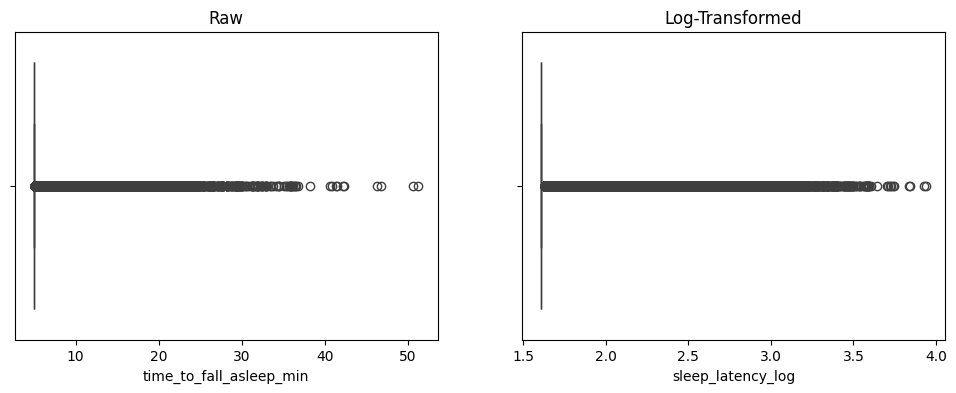

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=df['time_to_fall_asleep_min'], ax=ax[0])
ax[0].set_title("Raw")

sns.boxplot(x=df['sleep_latency_log'], ax=ax[1])
ax[1].set_title("Log-Transformed")

plt.show()

Untuk outlier pada time_to_fall_asleep_min perlu dicek kembali karena nilai terbanyak berada pada 5 menit, kemungkinan:
- 5 menit nilai patokan dari aplikasi, sehingga dibawah 5 menit masih masuk ke kategori tersebut
- 5-20 menit adalah waktu ideal untuk bisa tidur, sehingga banyak user yang tidur di rentang waktu 5 menit.
  
Maka dari itu, kolom time_to_fall_asleep belum digunakan untuk analisis, karena kurang merepersentasikan perilaku user

In [70]:
outlier_cols = [
    "hr_zone_1_min",
    "hr_zone_5_min",
    "sleep_efficiency",
    "hr_zone_4_min",
    "wake_ups",
    "activity_calories",
    "respiratory_rate",
    "weight_kg",
    "sleep_hours",
    "light_sleep_hours",
    "skin_temp_deviation",
    "hr_zone_3_min",
    "rem_sleep_hours",
    "hr_zone_2_min",
    "deep_sleep_hours",
    "calories_burned",
    "recovery_score"
]

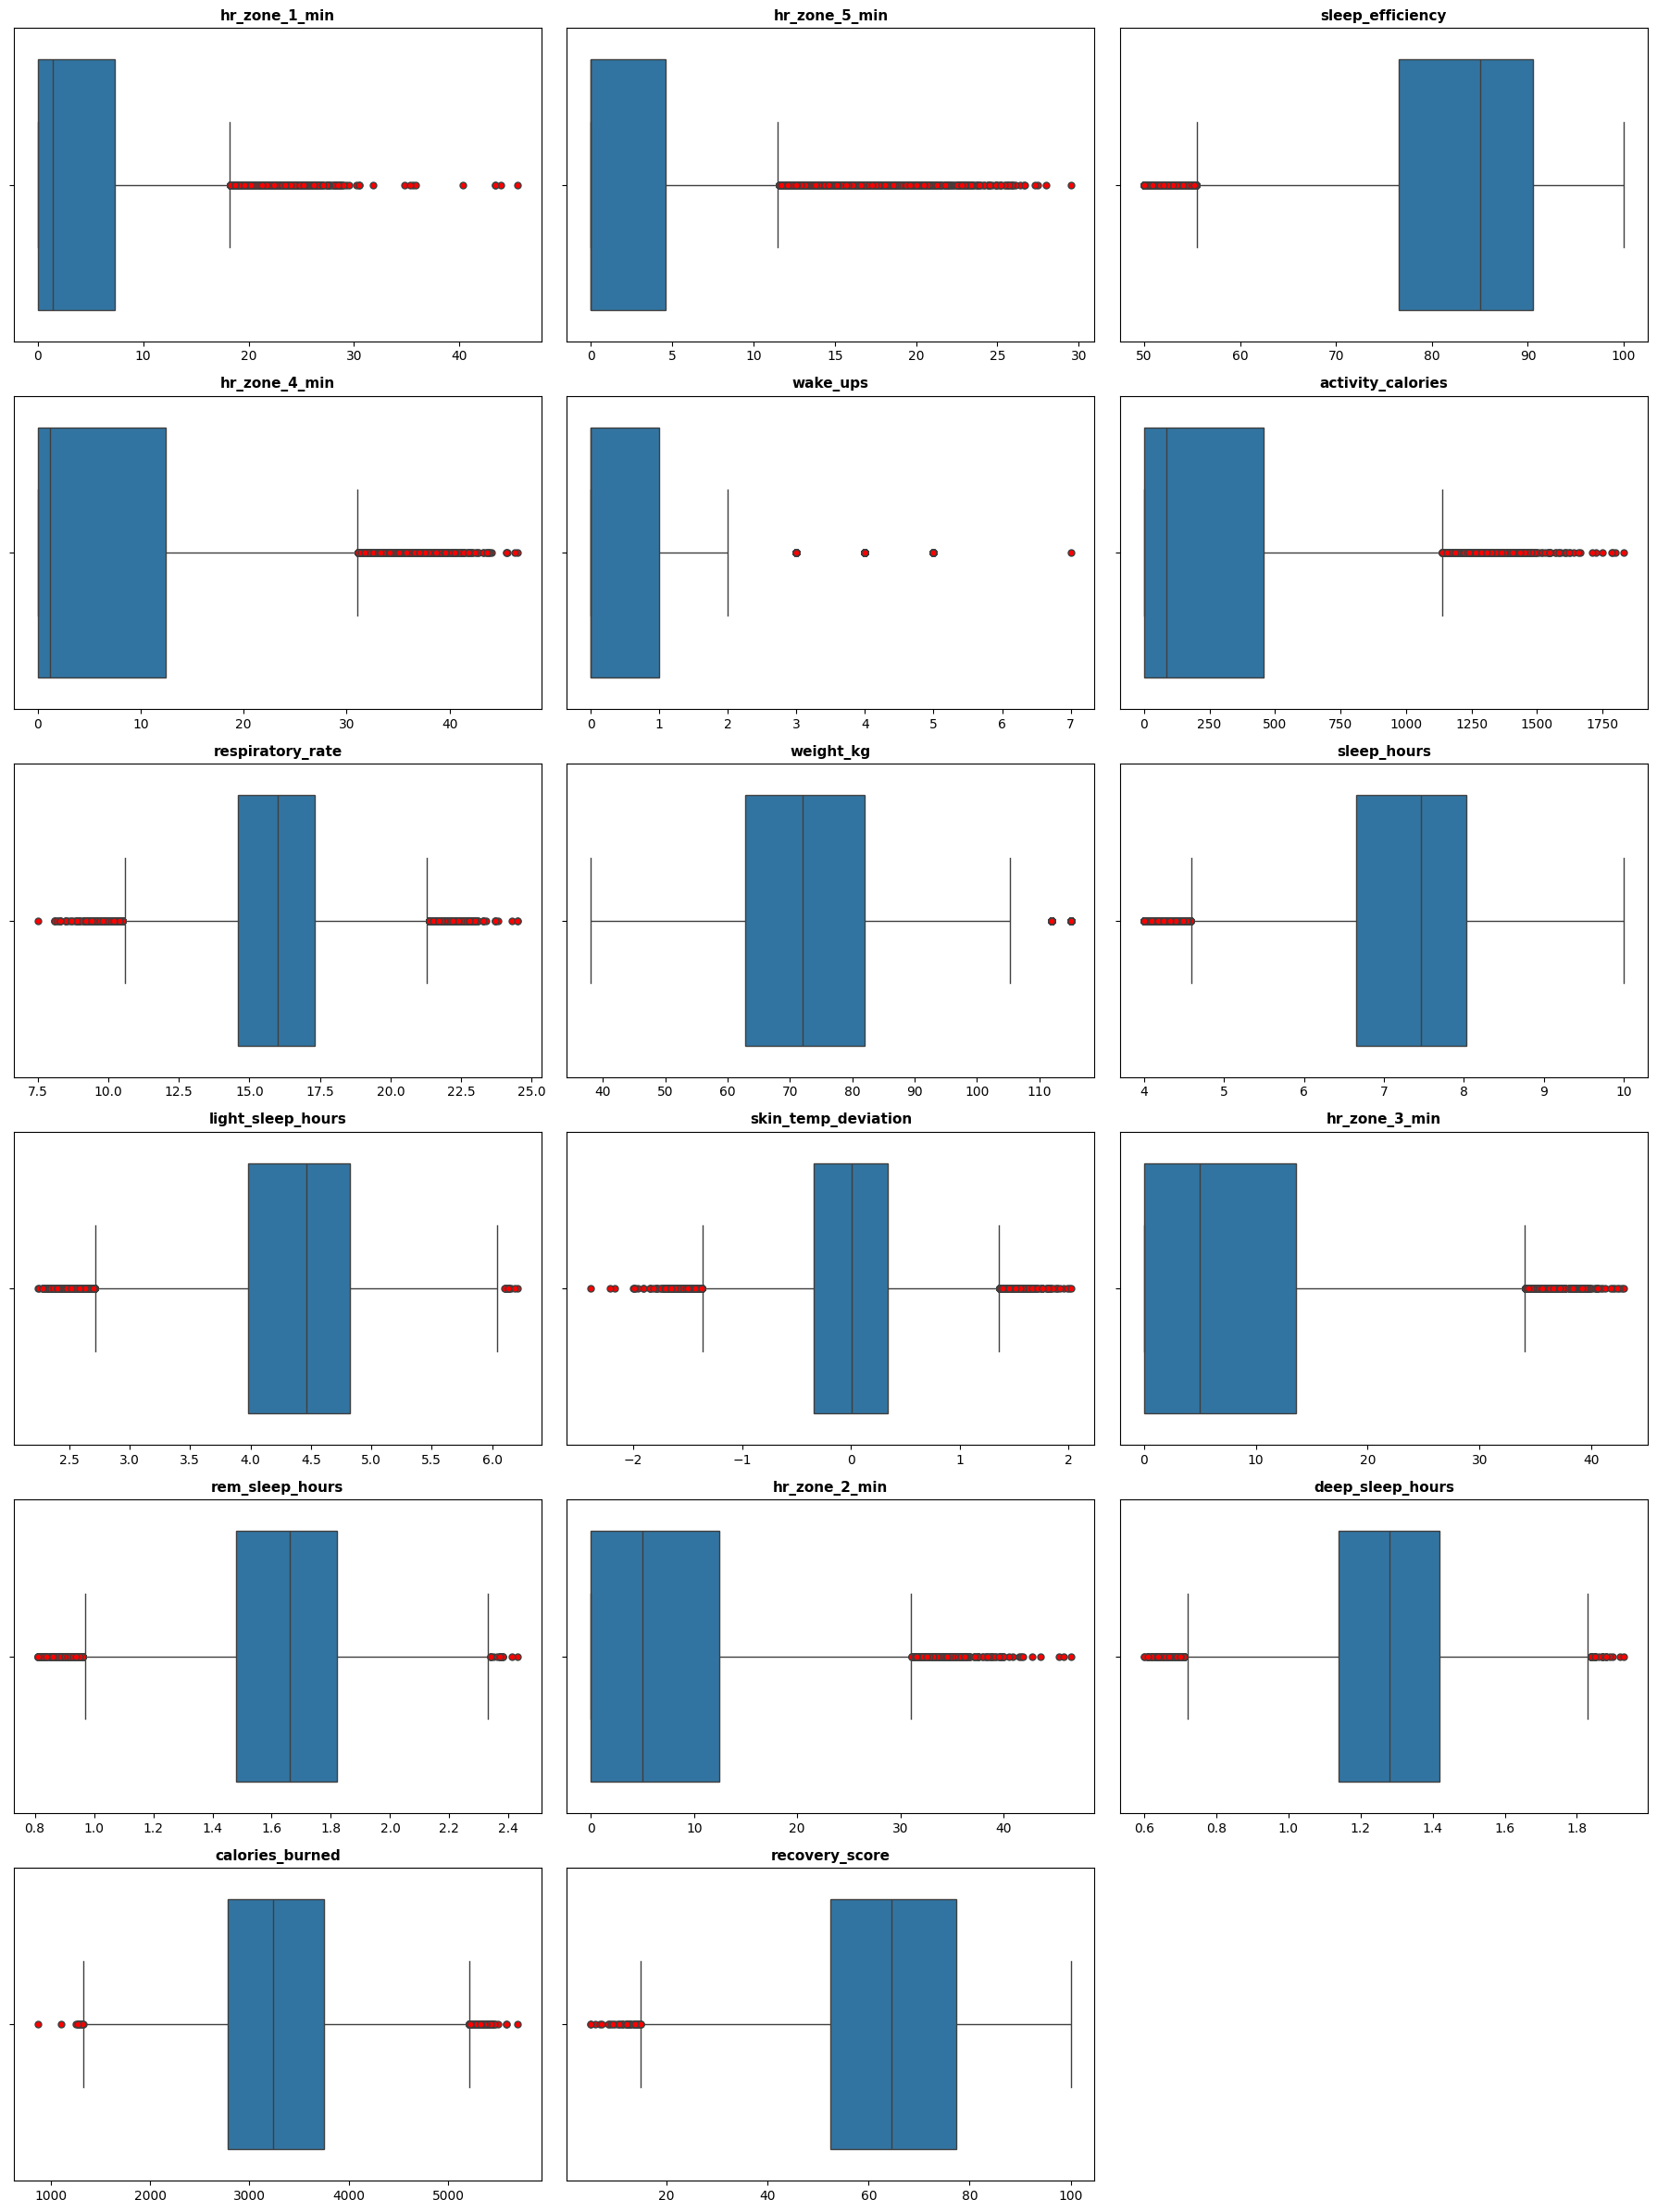

In [71]:
import math

cols = 3
rows = math.ceil(len(outlier_cols) / cols)

plt.figure(figsize=(18, 4 * rows))

for i, col in enumerate(outlier_cols, 1):
    plt.subplot(rows, cols, i)

    sns.boxplot(
        x=df[col],
        flierprops=dict(
            marker='o',
            markerfacecolor='red',
            markersize=5,
            linestyle='none'
        )
    )

    plt.title(col, fontsize=11, fontweight='bold')
    plt.xlabel("")

plt.tight_layout()
plt.show()

Variabel-variabel di atas tidak memerlukan perlakuan khusus terkait outlier. Nilai yang tampil sebagai “outlier” secara statistik tetap masuk akal secara fisiologis, sehingga dibiarkan apa adanya tanpa transformasi atau proses pembersihan tambahan. Untuk nilai di hr_zone, activity calories, dan lain-lain yang mengandung banyak nilai 0, terjadi karena tidak melakukan aktivitas apa-apa sehingga terbaca 0.

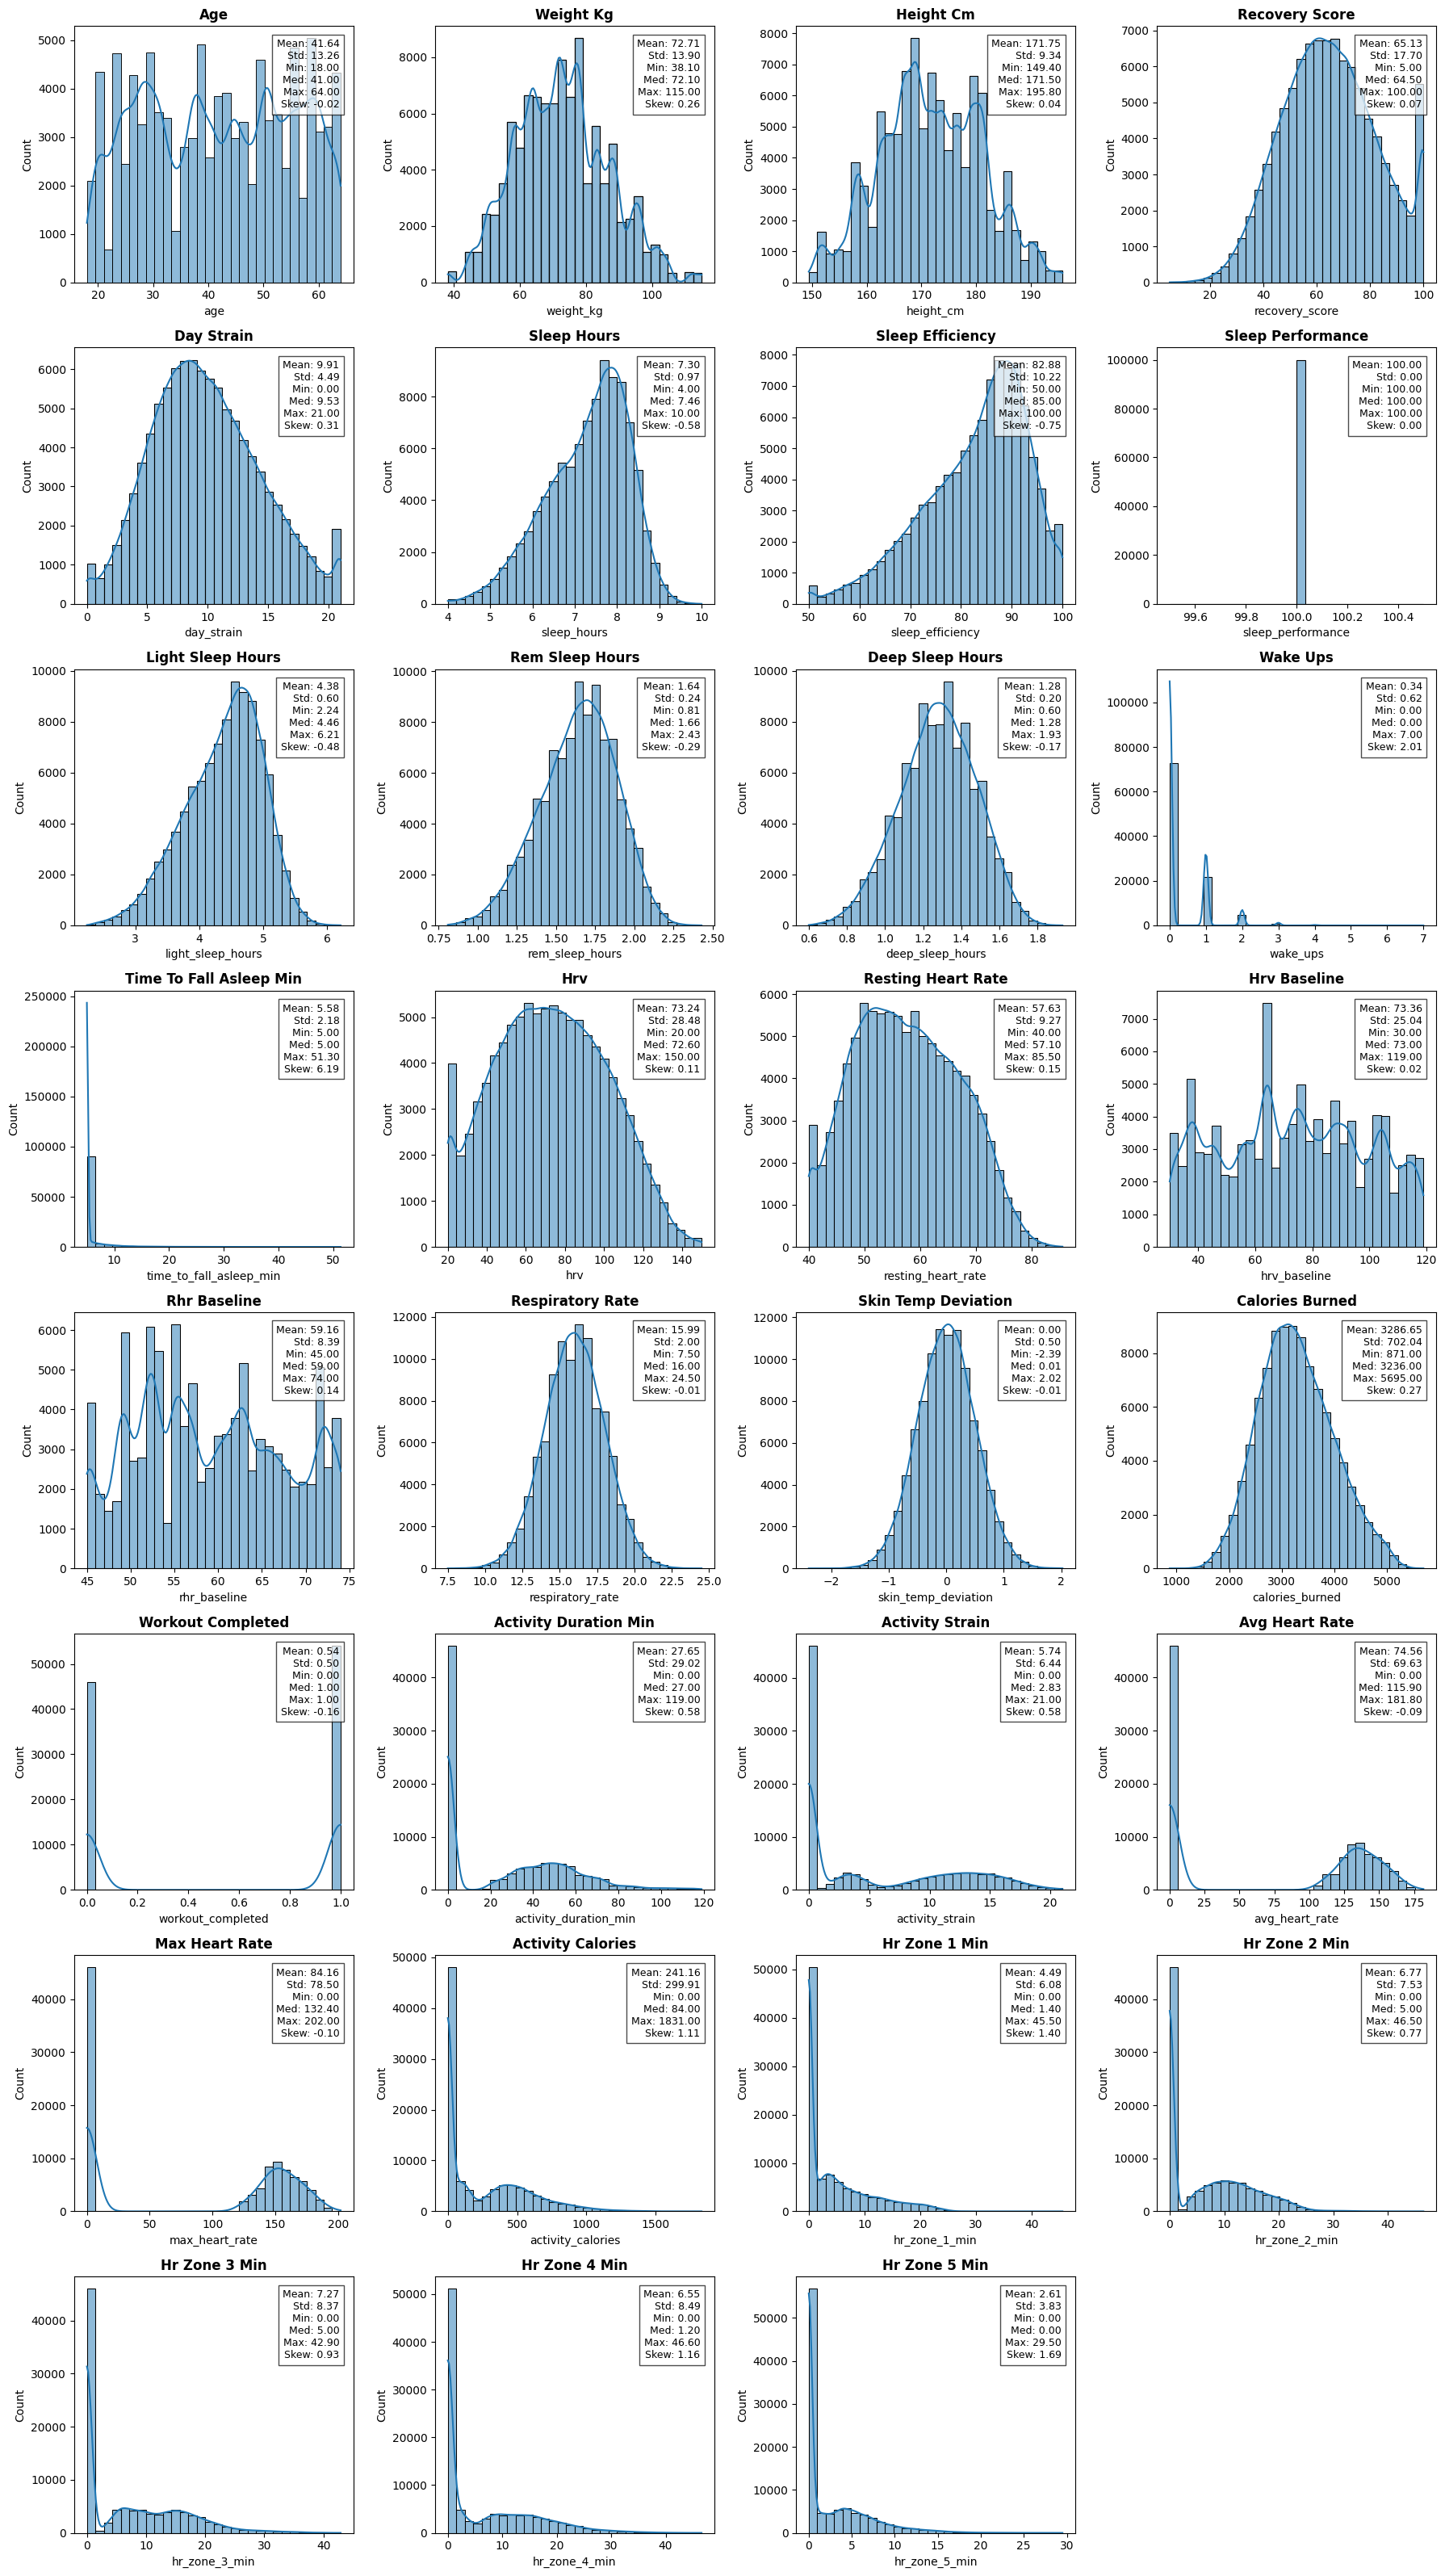

In [72]:
cols = 4
rows = math.ceil(len(num_cols) / cols)
plt.figure(figsize=(18,4*rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, 4, i)
    

    sns.histplot(df[col], kde=True, bins=30)
        
        # memasukan statistik deskriptif
    mean_val = df[col].mean()
    std_val = df[col].std()
    med_val = df[col].median()
    min_val = df[col].min()
    max_val = df[col].max()
    skew_val = df[col].skew()
        
        # memunculkan teks gambaran statistik deskriptif
    text_stats = (
        f"Mean: {mean_val:.2f}\n"
        f"Std: {std_val:.2f}\n"
        f"Min: {min_val:.2f}\n"
        f"Med: {med_val:.2f}\n"
        f"Max: {max_val:.2f}\n"
        f"Skew: {skew_val:.2f}"
        )
    plt.text(0.95, 0.95, text_stats, # memunculkan text box
            ha='right', va='top', transform=plt.gca().transAxes, # merubah koordinat text box menjadi milik chart
            fontsize=9, bbox=dict(facecolor='white', alpha=0.7)) # merancang text box agar mudah dilihat (opacity dll.)
        
    plt.title(col.replace('_', ' ').title(), fontweight='bold')
    plt.tight_layout()

plt.show()

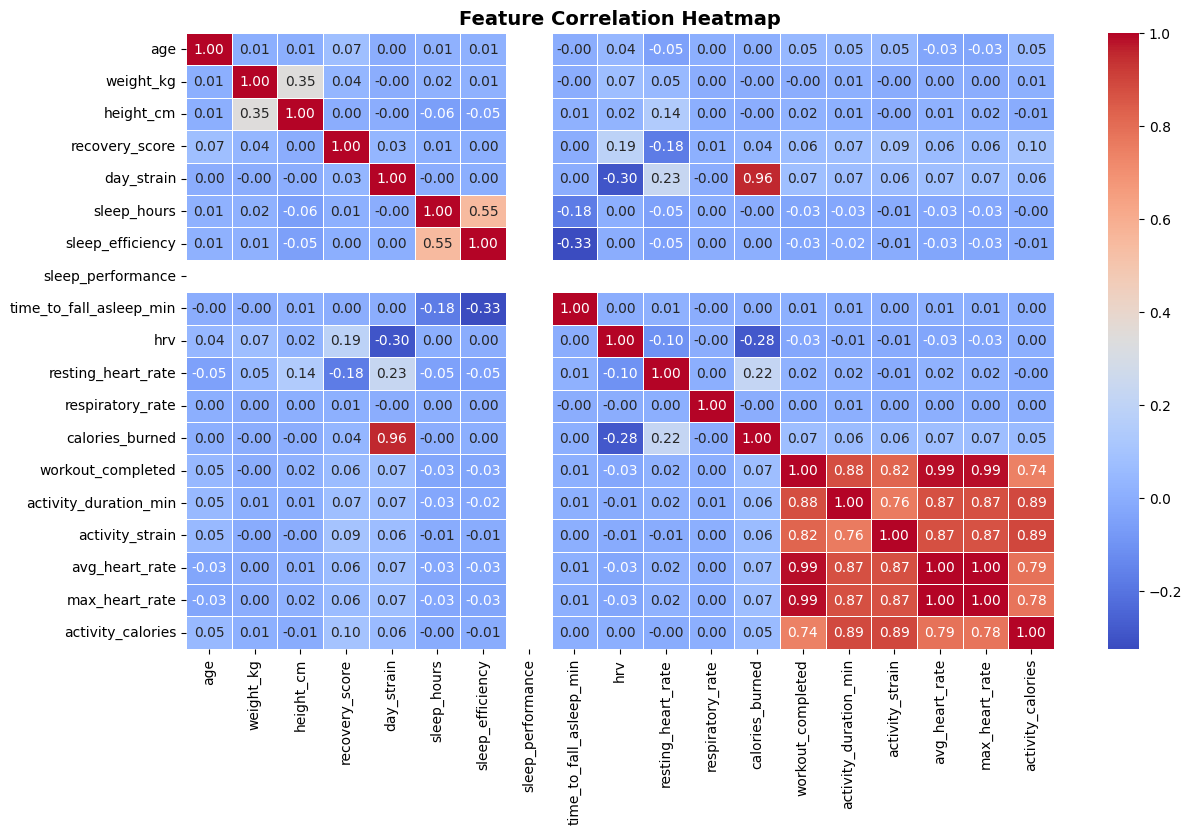

In [73]:
top_features =['age', 'weight_kg', 'height_cm', 'recovery_score', 'day_strain',
       'sleep_hours', 'sleep_efficiency', 'sleep_performance',
       'time_to_fall_asleep_min', 'hrv', 'resting_heart_rate', 'respiratory_rate',#'hrv_baseline',
       #'rhr_baseline', 
               'calories_burned', 'workout_completed',
       'activity_duration_min', 'activity_strain', 'avg_heart_rate',
       'max_heart_rate', 'activity_calories', 
               #'hr_zone_1_min', 'hr_zone_2_min',
       #'hr_zone_3_min', 'hr_zone_4_min', 'hr_zone_5_min'
              ]

# Select only the desired columns
df_corr = df[top_features]

# Create correlation matrix
co_mtx = df_corr.corr()

# Plot heatmap
plt.figure(figsize=(14,8))
sns.heatmap(
    co_mtx,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.show()

- Kolom activity_strain, activity calories, avg heart rate, dll. saling berkaitan namun pada level activity saja, tidak memperlihatkan perilaku user dalam keseharian.
- Kolom day strain memilki korelasi terhadap calories burned yang menjadi indikator beban kerja tubuh dalam kegiatan sehari-hari
- Kolom sleep performance tidak dapat digunakan dalam analisis karena hanya mengandung nilai 100, perlu ditelusuri di sesi lain.

# Feature Engineering

In [74]:
df_user = df.groupby("user_id").agg({
    "age":"first",
    "gender":"first",
    "fitness_level":"first",
    "primary_sport":"first",
    "day_strain":"mean",
    "activity_strain":"mean",
    "recovery_score":"mean",
    "sleep_hours":"mean",
    "sleep_efficiency":"mean",
    "activity_duration_min":"mean",
    "calories_burned":"mean",
    "workout_completed":"mean",
    "hrv":"mean",
    "resting_heart_rate":"mean"
}).reset_index()
df_user

,user_id,age,gender,fitness_level,primary_sport,day_strain,activity_strain,recovery_score,sleep_hours,sleep_efficiency,activity_duration_min,calories_burned,workout_completed,hrv,resting_heart_rate
0,USER_00001,56,Female,Beginner,Weight Training,10.008731,3.987368,73.412074,6.009071,70.819505,22.046440,3295.631579,0.396285,103.201858,56.774613
1,USER_00002,56,Male,Elite,CrossFit,9.387249,9.225663,54.032362,5.929256,70.426214,41.436893,3206.003236,0.754045,78.057282,47.487379
2,USER_00003,43,Male,Intermediate,Cycling,10.293815,3.786338,75.655077,6.023908,69.853538,22.283077,3352.806154,0.323077,62.820615,53.464000
3,USER_00004,36,Male,Advanced,CrossFit,9.711546,8.843091,65.308833,8.015426,90.084858,37.391167,3251.261830,0.665615,87.085804,58.261199
4,USER_00005,47,Female,Intermediate,Cycling,9.860878,4.702382,65.152351,7.016050,80.439498,30.097179,3282.777429,0.420063,57.353605,53.290596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,USER_00282,45,Female,Beginner,Yoga,9.707576,2.792298,63.992677,8.025657,90.050758,18.853535,3251.212121,0.398990,62.998737,55.409596
282,USER_00283,44,Female,Intermediate,CrossFit,9.801788,5.751637,64.971788,5.964257,70.119144,24.765743,3251.476071,0.430730,55.622670,50.336272
283,USER_00284,27,Female,Beginner,Running,10.366510,4.498880,64.771354,8.027734,90.184115,20.526042,3350.000000,0.364583,102.942969,47.897396
284,USER_00285,59,Male,Intermediate,Yoga,9.952727,2.394577,75.629781,8.010219,90.019436,17.934169,3305.579937,0.404389,108.192163,58.315361


In [75]:
df['user_id'].value_counts().sort_index()

user_id
USER_00001    323
USER_00002    309
USER_00003    325
USER_00004    317
USER_00005    319
             ... 
USER_00282    396
USER_00283    397
USER_00284    384
USER_00285    319
USER_00286    137
Name: count, Length: 286, dtype: int64

In [76]:
df_user.describe()

,age,day_strain,activity_strain,recovery_score,sleep_hours,sleep_efficiency,activity_duration_min,calories_burned,workout_completed,hrv,resting_heart_rate
count,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000,286.000000
mean,41.646853,9.912258,5.740121,65.153938,7.301173,82.933378,27.609691,3286.698640,0.539113,73.342067,57.642790
std,13.268791,0.235904,2.567322,8.791147,0.737600,7.372699,10.782669,38.172453,0.189737,25.028284,8.389818
min,18.000000,9.260712,1.362640,51.458376,5.924176,68.734761,9.165775,3149.278997,0.221574,28.297245,43.097345
25%,30.000000,9.758502,3.777568,54.763000,6.971155,79.613524,18.782179,3259.118239,0.386694,53.389600,50.454234
50%,41.500000,9.911243,5.150474,64.947392,7.047962,80.406642,24.918399,3287.108629,0.504400,72.413911,57.426709
75%,53.000000,10.079942,7.563423,74.617378,7.998618,89.935639,36.034238,3312.744957,0.722009,93.608182,64.514698
max,64.000000,10.446743,13.275271,77.826817,8.069526,90.598824,54.322884,3381.764205,0.925926,122.142627,73.691975


In [77]:
workout_dist = (
    df[df["workout_time_of_day"] != "No Workout"]
    .groupby(["user_id","workout_time_of_day"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
workout_dist

workout_time_of_day,user_id,Afternoon,Evening,Morning
0,USER_00001,34,40,54
1,USER_00002,72,71,90
2,USER_00003,35,26,44
3,USER_00004,62,67,82
4,USER_00005,45,37,52
...,...,...,...,...
281,USER_00282,48,38,72
282,USER_00283,48,45,78
283,USER_00284,41,51,48
284,USER_00285,34,39,56


In [78]:
preferred_time = (
    df[df["workout_time_of_day"] != "No Workout"]  # ignore no workout days
    .groupby("user_id")["workout_time_of_day"]
    .agg(lambda x: x.mode()[0])
    .reset_index(name="preferred_workout_time")
)
preferred_time['preferred_workout_time'].value_counts()

preferred_workout_time
Morning      250
Afternoon     19
Evening       17
Name: count, dtype: int64

In [79]:
df_user = df_user.merge(preferred_time, on="user_id", how="left")
df_user.head(5)

,user_id,age,gender,fitness_level,primary_sport,day_strain,activity_strain,recovery_score,sleep_hours,sleep_efficiency,activity_duration_min,calories_burned,workout_completed,hrv,resting_heart_rate,preferred_workout_time
0,USER_00001,56,Female,Beginner,Weight Training,10.008731,3.987368,73.412074,6.009071,70.819505,22.046440,3295.631579,0.396285,103.201858,56.774613,Morning
1,USER_00002,56,Male,Elite,CrossFit,9.387249,9.225663,54.032362,5.929256,70.426214,41.436893,3206.003236,0.754045,78.057282,47.487379,Morning
2,USER_00003,43,Male,Intermediate,Cycling,10.293815,3.786338,75.655077,6.023908,69.853538,22.283077,3352.806154,0.323077,62.820615,53.464000,Morning
3,USER_00004,36,Male,Advanced,CrossFit,9.711546,8.843091,65.308833,8.015426,90.084858,37.391167,3251.261830,0.665615,87.085804,58.261199,Morning
4,USER_00005,47,Female,Intermediate,Cycling,9.860878,4.702382,65.152351,7.016050,80.439498,30.097179,3282.777429,0.420063,57.353605,53.290596,Morning


In [80]:
num_cols = df_user.select_dtypes(include=['int64','float64']).columns
cat_cols = df_user.select_dtypes(include=['object','category']).columns

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: Index(['age', 'day_strain', 'activity_strain', 'recovery_score', 'sleep_hours',
       'sleep_efficiency', 'activity_duration_min', 'calories_burned',
       'workout_completed', 'hrv', 'resting_heart_rate'],
      dtype='object')
Categorical columns: Index(['user_id', 'gender', 'fitness_level', 'primary_sport',
       'preferred_workout_time'],
      dtype='object')


# Exploratory Data Analysis

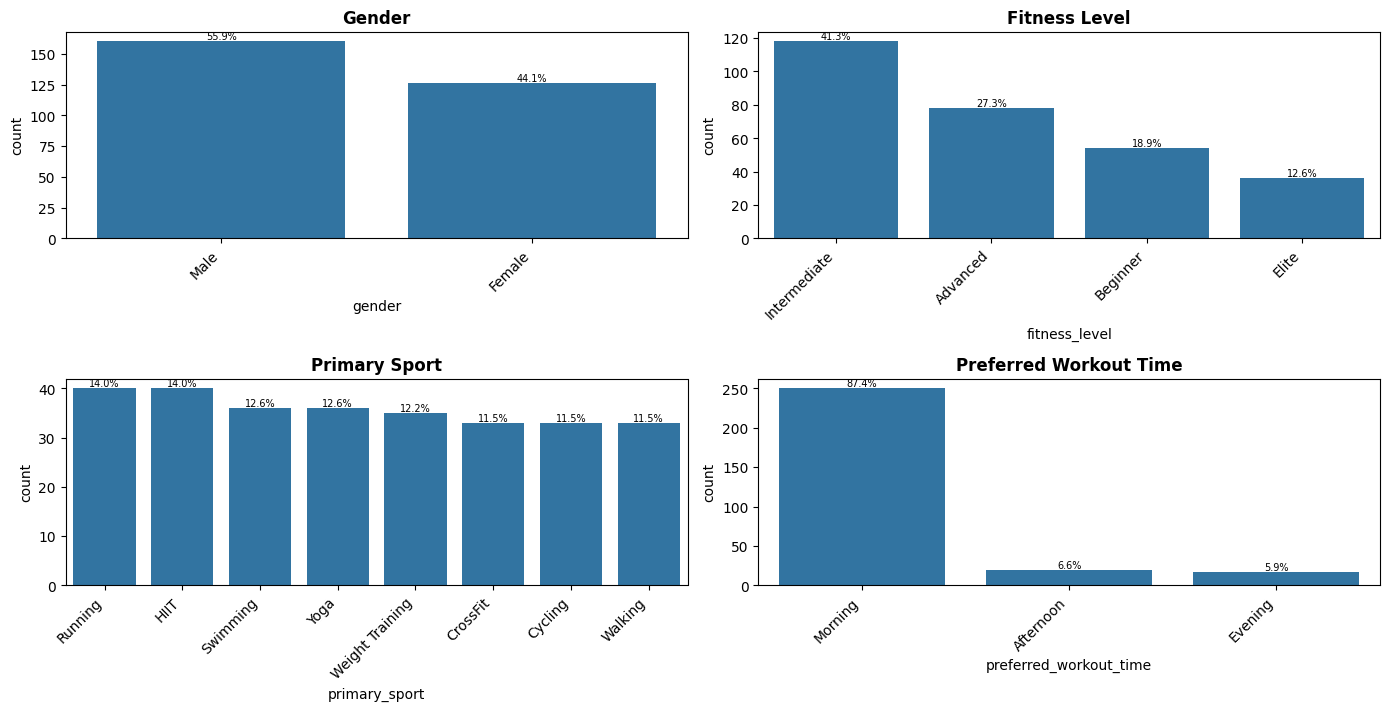

In [81]:
cat_cols = [#'user_id', 
    'gender', 'fitness_level', 'primary_sport',
       'preferred_workout_time']
plt.figure(figsize=(14,13))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(4, 2, i)

    # Count occurrences
    counts = df_user[col].value_counts()
    order = counts.index
    total = len(df_user)

    # Plot countplot
    ax = sns.countplot(data=df_user, x=col, order=order)
    # rotate labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    # Add percentage labels
    for p in ax.patches:
        height = p.get_height()
        percentage = (height / total) * 100
        ax.annotate(f'{percentage:.1f}%', 
                    (p.get_x() + p.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=7)

    plt.title(col.replace('_', ' ').title(), fontweight='bold')
    plt.tight_layout()

plt.show()

1. Jumlah user laki-laki lebih banyak dibandingkan perempuan
2. Mayoritas user sudah mengerti olahraga, mayoritas fitness level berada pada intermediate
3. Olahraga user cukup bervariatif mulai dari high-strength training (HIIT, Weight,Crossfit), cardio(swimming, running, cycling) sampai dengan low impact training (walking, yoga)
4. Mayoritas user melakukan olahraga di pagi hari


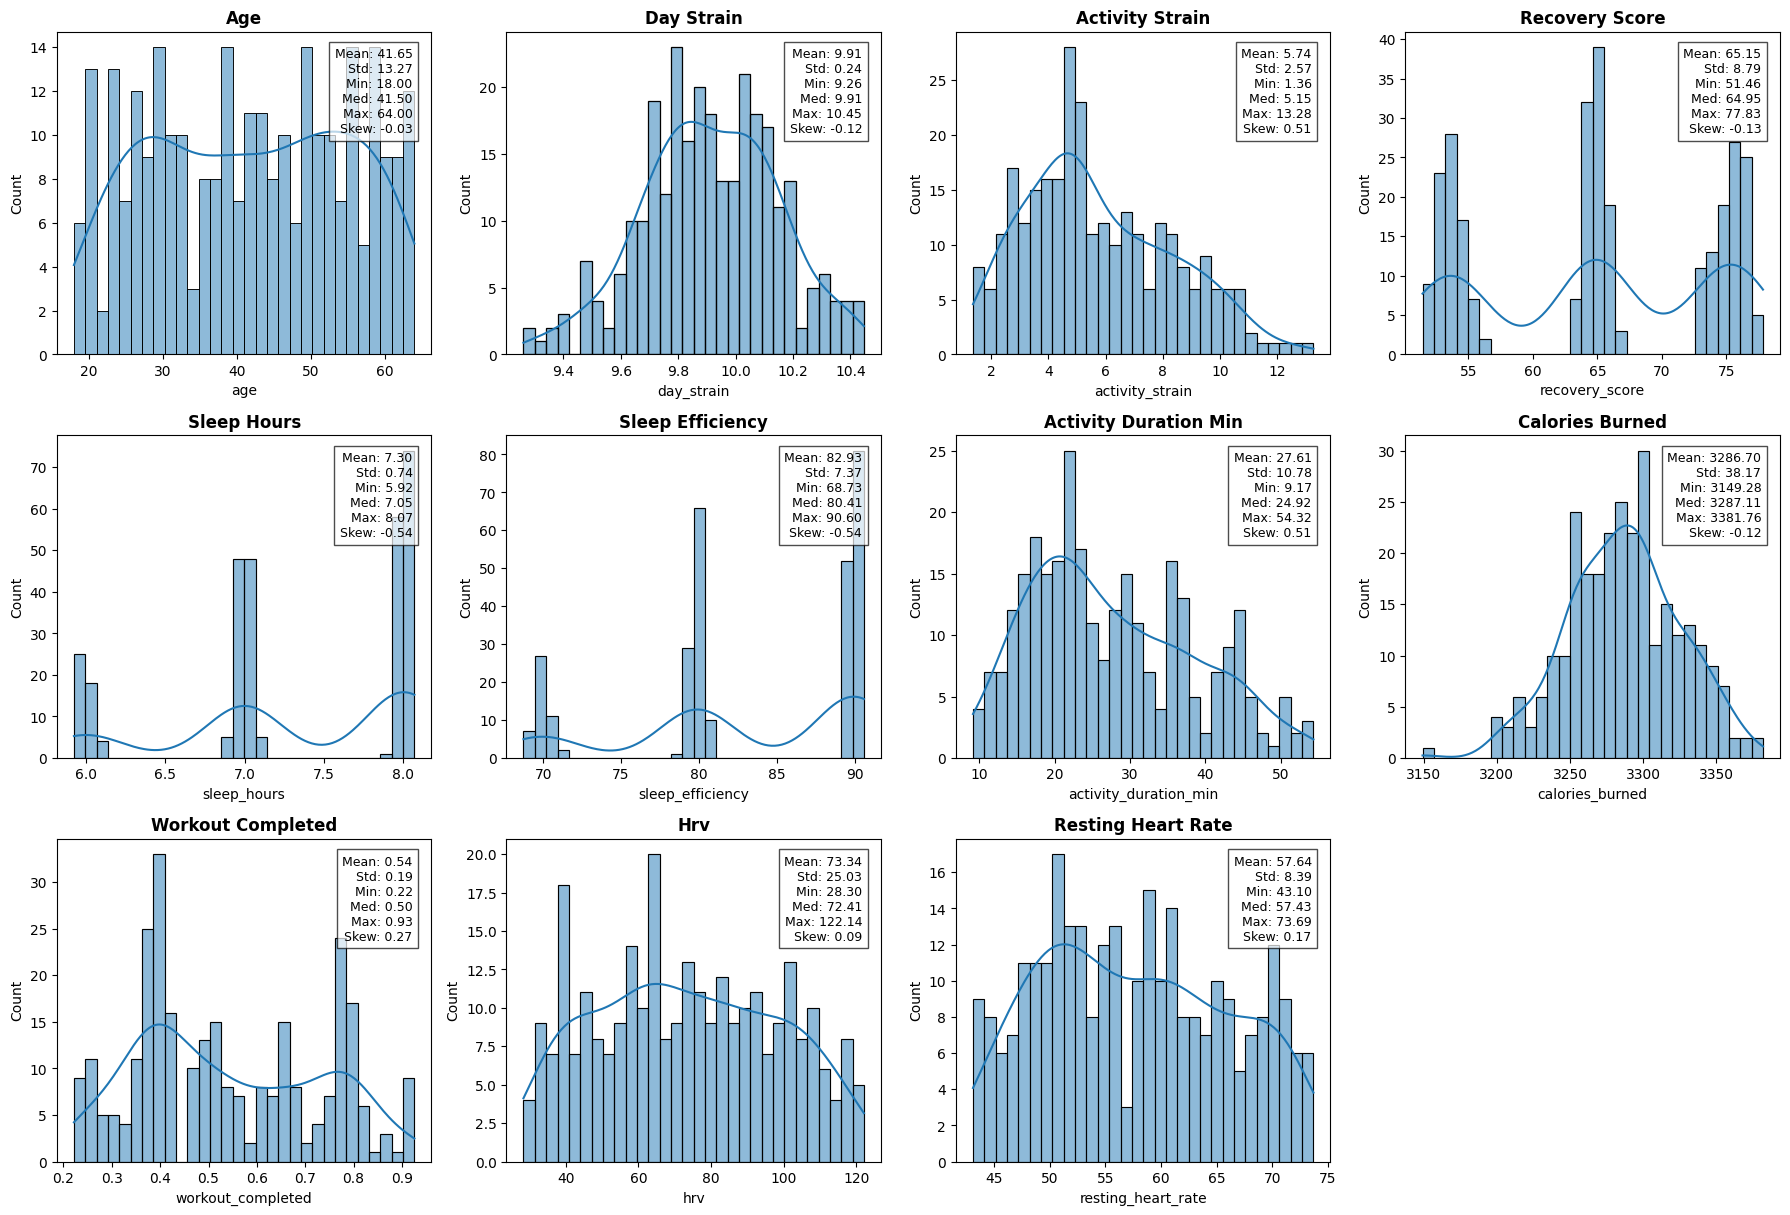

In [82]:
plt.figure(figsize=(18,4*rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, 4, i)
    

    sns.histplot(df_user[col], kde=True, bins=30)
        
        # memasukan statistik deskriptif
    mean_val = df_user[col].mean()
    std_val = df_user[col].std()
    med_val = df_user[col].median()
    min_val = df_user[col].min()
    max_val = df_user[col].max()
    skew_val = df_user[col].skew()
        
        # memunculkan teks gambaran statistik deskriptif
    text_stats = (
        f"Mean: {mean_val:.2f}\n"
        f"Std: {std_val:.2f}\n"
        f"Min: {min_val:.2f}\n"
        f"Med: {med_val:.2f}\n"
        f"Max: {max_val:.2f}\n"
        f"Skew: {skew_val:.2f}"
        )
    plt.text(0.95, 0.95, text_stats, # memunculkan text box
            ha='right', va='top', transform=plt.gca().transAxes, # merubah koordinat text box menjadi milik chart
            fontsize=9, bbox=dict(facecolor='white', alpha=0.7)) # merancang text box agar mudah dilihat (opacity dll.)
        
    plt.title(col.replace('_', ' ').title(), fontweight='bold')
    plt.tight_layout()

plt.show()

1. Populasi pengguna sangat beragam, baik dari usia, intensitas latihan, hingga pola tidur.
2. Strain harian cenderung moderat, mayoritas user berada pada zona strain sedang, bukan ekstrem.
3. Recovery menunjukkan pola tersegmentasi, mengindikasikan adanya kelompok dengan recovery sedang dan tinggi (Whoop-based).
4. Pola tidur terbagi menjadi 3 cluster alami: short(<6jam), moderat(6-7 jam), optimal (8 jam), berdasarkan WHO.
5. Frekuensi latihan cukup tinggi (0.54) namun variasinya besar — cocok dijadikan dasar segmentasi perilaku.
6. Variasi HRV dan RHR yang besar menunjukkan perbedaan fitness level yang signifikan antar user.
7. Data ini cocok untuk segmentasi berbasis aktivitas dan kebiasaan kesehatan, karena pola antar user sangat berbeda.

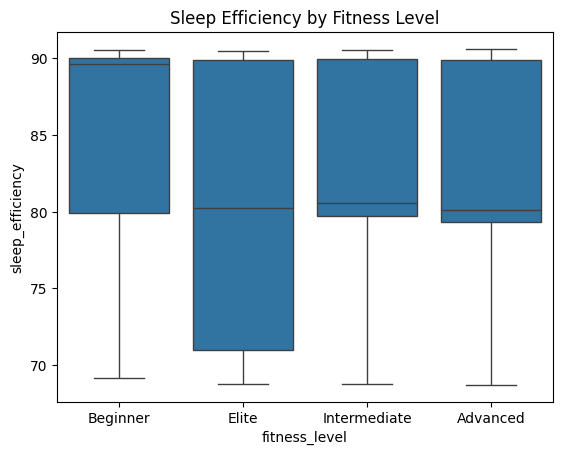

In [83]:
sns.boxplot(data=df_user, x='fitness_level', y='sleep_efficiency')
plt.title("Sleep Efficiency by Fitness Level")
plt.show()

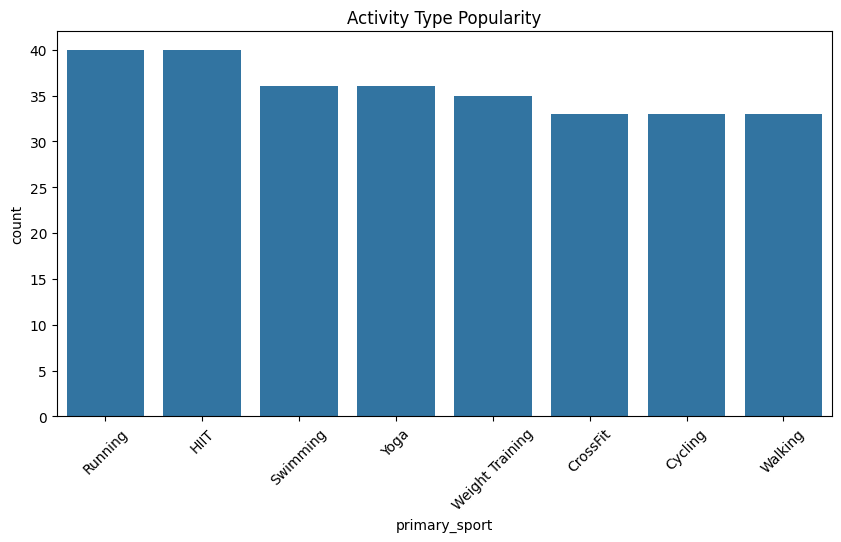

In [84]:
plt.figure(figsize=(10,5))
sns.countplot(data=df_user, x='primary_sport', order=df_user['primary_sport'].value_counts().index)
plt.xticks(rotation=45)
plt.title("Activity Type Popularity")
plt.show()


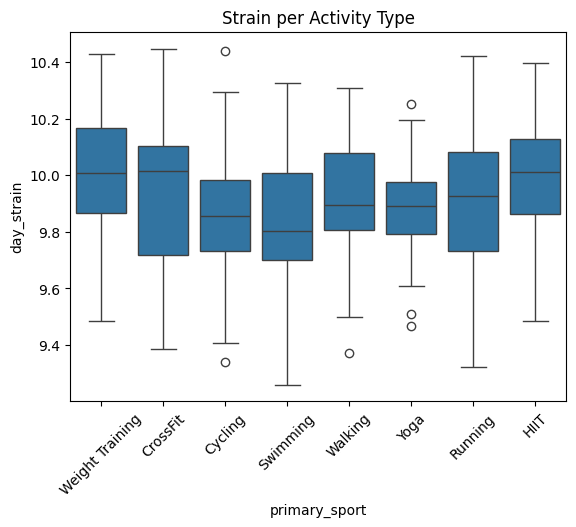

In [85]:
sns.boxplot(data=df_user, x='primary_sport', y='day_strain')
plt.xticks(rotation=45)
plt.title("Strain per Activity Type")
plt.show()

In [86]:
# Recovery Zone
def recovery_zone(x):
    if x >= 67: return 'Green (67-100%)'
    elif x >= 34: return 'Yellow (34-66%)'
    else: return 'Red (0-33%)'

df_user['recovery_zone'] = df_user['recovery_score'].apply(recovery_zone)
df_user.head(5)

,user_id,age,gender,fitness_level,primary_sport,day_strain,activity_strain,recovery_score,sleep_hours,sleep_efficiency,activity_duration_min,calories_burned,workout_completed,hrv,resting_heart_rate,preferred_workout_time,recovery_zone
0,USER_00001,56,Female,Beginner,Weight Training,10.008731,3.987368,73.412074,6.009071,70.819505,22.046440,3295.631579,0.396285,103.201858,56.774613,Morning,Green (67-100%)
1,USER_00002,56,Male,Elite,CrossFit,9.387249,9.225663,54.032362,5.929256,70.426214,41.436893,3206.003236,0.754045,78.057282,47.487379,Morning,Yellow (34-66%)
2,USER_00003,43,Male,Intermediate,Cycling,10.293815,3.786338,75.655077,6.023908,69.853538,22.283077,3352.806154,0.323077,62.820615,53.464000,Morning,Green (67-100%)
3,USER_00004,36,Male,Advanced,CrossFit,9.711546,8.843091,65.308833,8.015426,90.084858,37.391167,3251.261830,0.665615,87.085804,58.261199,Morning,Yellow (34-66%)
4,USER_00005,47,Female,Intermediate,Cycling,9.860878,4.702382,65.152351,7.016050,80.439498,30.097179,3282.777429,0.420063,57.353605,53.290596,Morning,Yellow (34-66%)


# feature engineering after EDA


In [87]:
# Recovery Zone
def recovery_zone(x):
    if x >= 67: return 'Green (67-100%)'
    elif x >= 34: return 'Yellow (34-66%)'
    else: return 'Red (0-33%)'

df_user['recovery_zone'] = df_user['recovery_score'].apply(recovery_zone)
df_user.head(5)

,user_id,age,gender,fitness_level,primary_sport,day_strain,activity_strain,recovery_score,sleep_hours,sleep_efficiency,activity_duration_min,calories_burned,workout_completed,hrv,resting_heart_rate,preferred_workout_time,recovery_zone
0,USER_00001,56,Female,Beginner,Weight Training,10.008731,3.987368,73.412074,6.009071,70.819505,22.046440,3295.631579,0.396285,103.201858,56.774613,Morning,Green (67-100%)
1,USER_00002,56,Male,Elite,CrossFit,9.387249,9.225663,54.032362,5.929256,70.426214,41.436893,3206.003236,0.754045,78.057282,47.487379,Morning,Yellow (34-66%)
2,USER_00003,43,Male,Intermediate,Cycling,10.293815,3.786338,75.655077,6.023908,69.853538,22.283077,3352.806154,0.323077,62.820615,53.464000,Morning,Green (67-100%)
3,USER_00004,36,Male,Advanced,CrossFit,9.711546,8.843091,65.308833,8.015426,90.084858,37.391167,3251.261830,0.665615,87.085804,58.261199,Morning,Yellow (34-66%)
4,USER_00005,47,Female,Intermediate,Cycling,9.860878,4.702382,65.152351,7.016050,80.439498,30.097179,3282.777429,0.420063,57.353605,53.290596,Morning,Yellow (34-66%)


In [88]:
df_user['recovery_zone'].value_counts().sort_index()

recovery_zone
Green (67-100%)    100
Yellow (34-66%)    186
Name: count, dtype: int64

In [89]:
def strain_category(x):
    if x < 10:
        return "Light"
    elif x >= 10 and x <= 13:
        return "Moderate"
    elif x <= 17:
        return "High"
    else:
        return "All Out"

df_user["strain_level"] = df_user["day_strain"].apply(strain_category)
df_user.head(5)

,user_id,age,gender,fitness_level,primary_sport,day_strain,activity_strain,recovery_score,sleep_hours,sleep_efficiency,activity_duration_min,calories_burned,workout_completed,hrv,resting_heart_rate,preferred_workout_time,recovery_zone,strain_level
0,USER_00001,56,Female,Beginner,Weight Training,10.008731,3.987368,73.412074,6.009071,70.819505,22.046440,3295.631579,0.396285,103.201858,56.774613,Morning,Green (67-100%),Moderate
1,USER_00002,56,Male,Elite,CrossFit,9.387249,9.225663,54.032362,5.929256,70.426214,41.436893,3206.003236,0.754045,78.057282,47.487379,Morning,Yellow (34-66%),Light
2,USER_00003,43,Male,Intermediate,Cycling,10.293815,3.786338,75.655077,6.023908,69.853538,22.283077,3352.806154,0.323077,62.820615,53.464000,Morning,Green (67-100%),Moderate
3,USER_00004,36,Male,Advanced,CrossFit,9.711546,8.843091,65.308833,8.015426,90.084858,37.391167,3251.261830,0.665615,87.085804,58.261199,Morning,Yellow (34-66%),Light
4,USER_00005,47,Female,Intermediate,Cycling,9.860878,4.702382,65.152351,7.016050,80.439498,30.097179,3282.777429,0.420063,57.353605,53.290596,Morning,Yellow (34-66%),Light


In [90]:
df_user["strain_level"].value_counts()

strain_level
Light       175
Moderate    111
Name: count, dtype: int64

In [91]:
def behavior_segment(row):

    strain = row["day_strain"]
    recovery = row["recovery_score"]

    if strain >= 10 and recovery >= 67:
        return "Active & Ready"

    elif strain >= 10 and recovery < 67:
        return "Pushing Hard"

    elif strain < 10 and recovery >= 67:
        return "Rested but Lightly Active"

    else:
        return "Low Activity"


df_user["behavior_segment"] = df_user.apply(behavior_segment, axis=1)
df_user

,user_id,age,gender,fitness_level,primary_sport,day_strain,activity_strain,recovery_score,sleep_hours,sleep_efficiency,activity_duration_min,calories_burned,workout_completed,hrv,resting_heart_rate,preferred_workout_time,recovery_zone,strain_level,behavior_segment
0,USER_00001,56,Female,Beginner,Weight Training,10.008731,3.987368,73.412074,6.009071,70.819505,22.046440,3295.631579,0.396285,103.201858,56.774613,Morning,Green (67-100%),Moderate,Active & Ready
1,USER_00002,56,Male,Elite,CrossFit,9.387249,9.225663,54.032362,5.929256,70.426214,41.436893,3206.003236,0.754045,78.057282,47.487379,Morning,Yellow (34-66%),Light,Low Activity
2,USER_00003,43,Male,Intermediate,Cycling,10.293815,3.786338,75.655077,6.023908,69.853538,22.283077,3352.806154,0.323077,62.820615,53.464000,Morning,Green (67-100%),Moderate,Active & Ready
3,USER_00004,36,Male,Advanced,CrossFit,9.711546,8.843091,65.308833,8.015426,90.084858,37.391167,3251.261830,0.665615,87.085804,58.261199,Morning,Yellow (34-66%),Light,Low Activity
4,USER_00005,47,Female,Intermediate,Cycling,9.860878,4.702382,65.152351,7.016050,80.439498,30.097179,3282.777429,0.420063,57.353605,53.290596,Morning,Yellow (34-66%),Light,Low Activity
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,USER_00282,45,Female,Beginner,Yoga,9.707576,2.792298,63.992677,8.025657,90.050758,18.853535,3251.212121,0.398990,62.998737,55.409596,Morning,Yellow (34-66%),Light,Low Activity
282,USER_00283,44,Female,Intermediate,CrossFit,9.801788,5.751637,64.971788,5.964257,70.119144,24.765743,3251.476071,0.430730,55.622670,50.336272,Morning,Yellow (34-66%),Light,Low Activity
283,USER_00284,27,Female,Beginner,Running,10.366510,4.498880,64.771354,8.027734,90.184115,20.526042,3350.000000,0.364583,102.942969,47.897396,Evening,Yellow (34-66%),Moderate,Pushing Hard
284,USER_00285,59,Male,Intermediate,Yoga,9.952727,2.394577,75.629781,8.010219,90.019436,17.934169,3305.579937,0.404389,108.192163,58.315361,Morning,Green (67-100%),Light,Rested but Lightly Active


In [92]:
df_user["behavior_segment"].value_counts()

behavior_segment
Low Activity                 124
Pushing Hard                  62
Rested but Lightly Active     51
Active & Ready                49
Name: count, dtype: int64

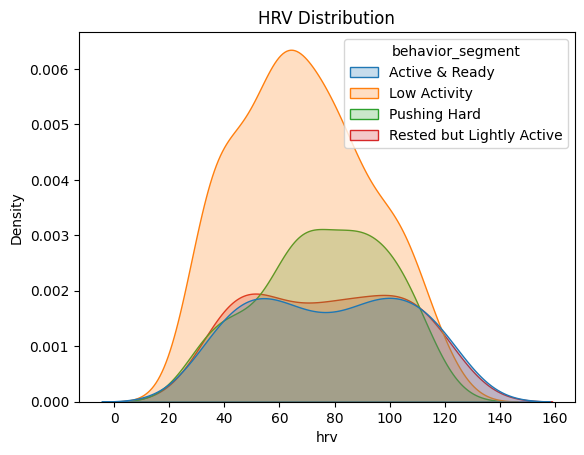

In [93]:
sns.kdeplot(data=df_user, x='hrv', hue='behavior_segment', fill=True)
plt.title("HRV Distribution")
plt.show()

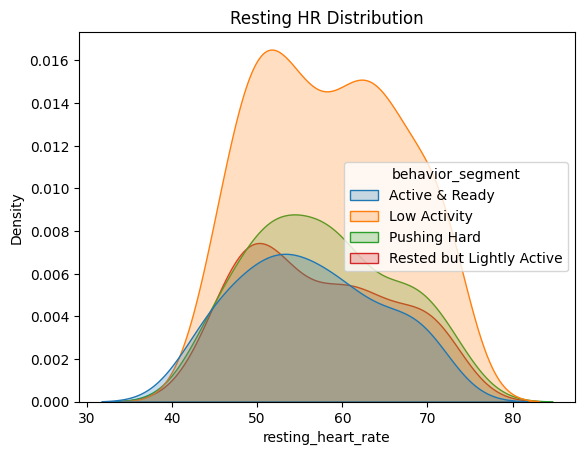

In [94]:
sns.kdeplot(data=df_user, x='resting_heart_rate',fill=True,hue='behavior_segment')
plt.title("Resting HR Distribution")
plt.show()

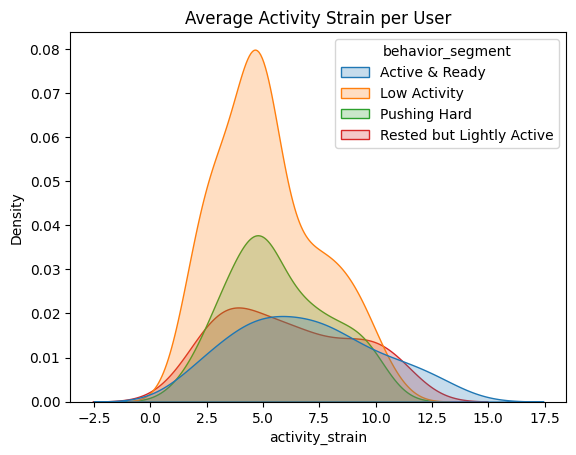

In [95]:
sns.kdeplot(data=df_user,x="activity_strain", fill=True,hue='behavior_segment')
plt.title("Average Activity Strain per User")
plt.show()

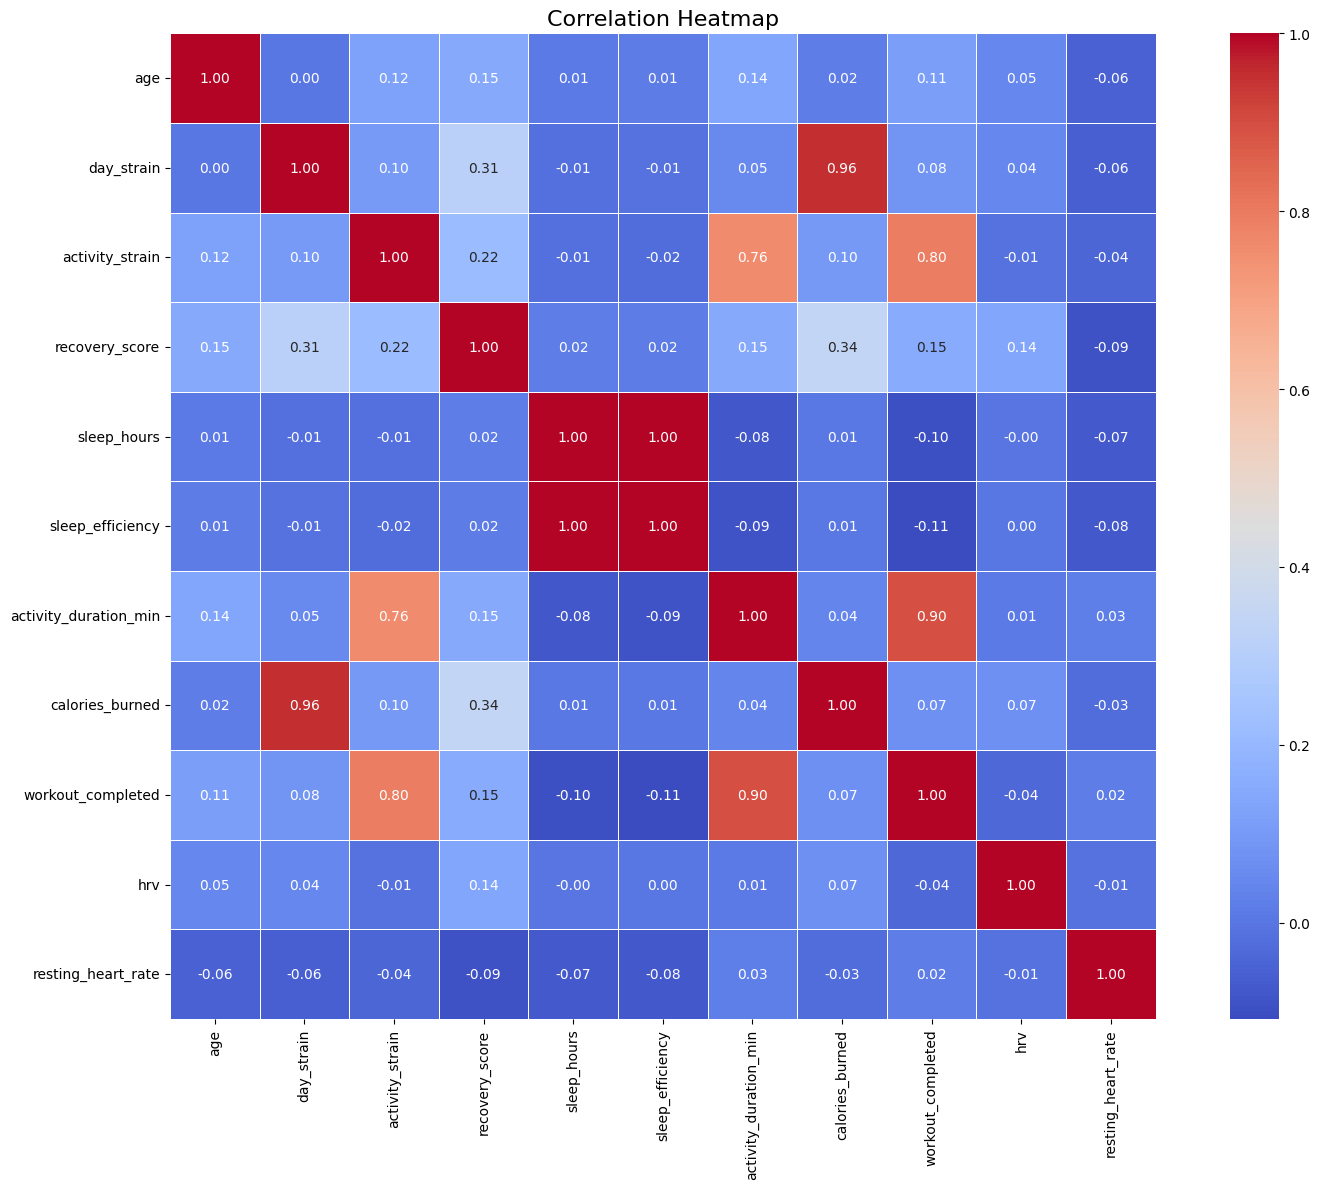

In [96]:
corr_matrix = df_user.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

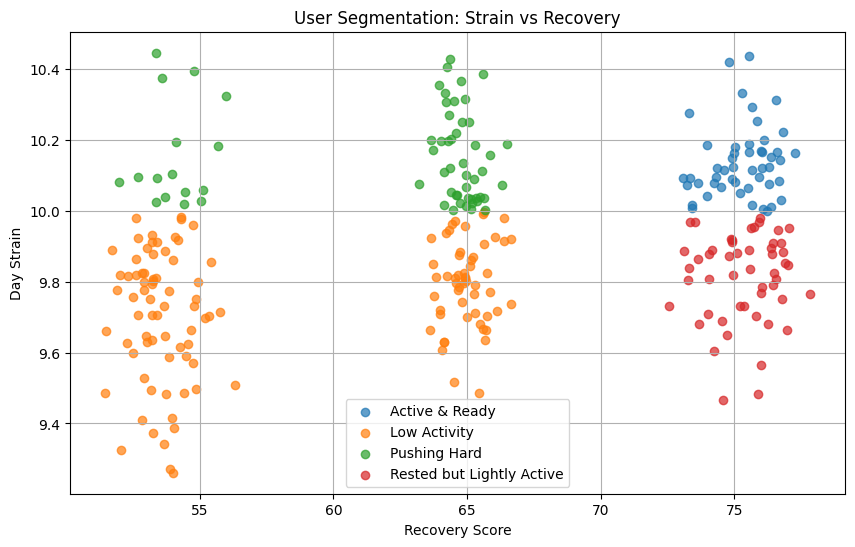

In [97]:
plt.figure(figsize=(10,6))

segments = df_user["behavior_segment"].unique()

for segment in segments:
    subset = df_user[df_user["behavior_segment"] == segment]
    plt.scatter(
        subset["recovery_score"],
        subset["day_strain"],
        label=segment,
        alpha=0.7
    )

plt.xlabel("Recovery Score")
plt.ylabel("Day Strain")
plt.title("User Segmentation: Strain vs Recovery")
plt.legend()
plt.grid(True)

plt.show()

In [98]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_user[['strain_scaled','recovery_scaled']] = scaler.fit_transform(
    df_user[['day_strain','recovery_score']]
)
df_user.head(5)

,user_id,age,gender,fitness_level,primary_sport,day_strain,activity_strain,recovery_score,sleep_hours,sleep_efficiency,activity_duration_min,calories_burned,workout_completed,hrv,resting_heart_rate,preferred_workout_time,recovery_zone,strain_level,behavior_segment,strain_scaled,recovery_scaled
0,USER_00001,56,Female,Beginner,Weight Training,10.008731,3.987368,73.412074,6.009071,70.819505,22.046440,3295.631579,0.396285,103.201858,56.774613,Morning,Green (67-100%),Moderate,Active & Ready,0.630691,0.832575
1,USER_00002,56,Male,Elite,CrossFit,9.387249,9.225663,54.032362,5.929256,70.426214,41.436893,3206.003236,0.754045,78.057282,47.487379,Morning,Yellow (34-66%),Light,Low Activity,0.106689,0.097616
2,USER_00003,43,Male,Intermediate,Cycling,10.293815,3.786338,75.655077,6.023908,69.853538,22.283077,3352.806154,0.323077,62.820615,53.464000,Morning,Green (67-100%),Moderate,Active & Ready,0.871059,0.917639
3,USER_00004,36,Male,Advanced,CrossFit,9.711546,8.843091,65.308833,8.015426,90.084858,37.391167,3251.261830,0.665615,87.085804,58.261199,Morning,Yellow (34-66%),Light,Low Activity,0.380120,0.525266
4,USER_00005,47,Female,Intermediate,Cycling,9.860878,4.702382,65.152351,7.016050,80.439498,30.097179,3282.777429,0.420063,57.353605,53.290596,Morning,Yellow (34-66%),Light,Low Activity,0.506029,0.519332


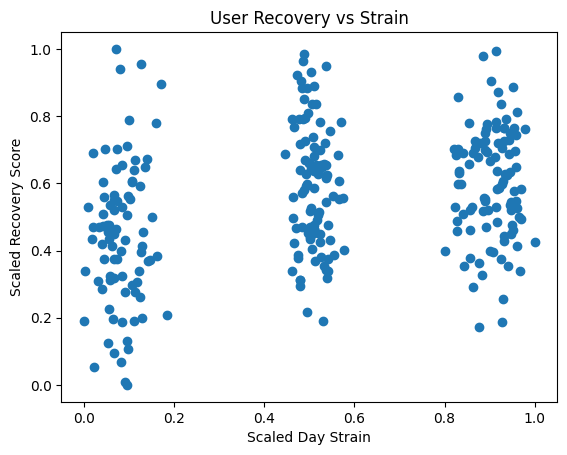

In [99]:
plt.scatter(df_user['recovery_scaled'], df_user['strain_scaled'])
plt.xlabel('Scaled Day Strain')
plt.ylabel('Scaled Recovery Score')
plt.title('User Recovery vs Strain')
plt.show()

In [59]:
df_user.to_csv(r'C:\Users\ASUS\Downloads\latihan Netflix\user_segmentation_whoop(REV2).csv')

In [ ]:
# Optional CLustering using KMeans
# Not used

In [101]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
X = df_user[["day_strain", "recovery_score"]]
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:

inertia = []
k_range = range(1,10)

for k in k_range:
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia (Within-Cluster Variance)")
plt.title("Elbow Method for Optimal Clusters")

plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
silhouette_scores = []

for k in range(2,10):
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Find best k
best_k = range(2,10)[silhouette_scores.index(max(silhouette_scores))]
print("Best number of clusters:", best_k)
print("Best silhouette score:", max(silhouette_scores))

# Plot
plt.figure(figsize=(8,5))
plt.plot(range(2,10), silhouette_scores, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal Clusters")

plt.grid(True)
plt.show()

In [104]:
kmeans = KMeans(n_clusters=8, random_state=42)

df_user["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

In [ ]:
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

centroid_df = pd.DataFrame(
    centroids,
    columns=["day_strain","recovery_score"]
)

print(centroid_df)

In [ ]:
plt.figure(figsize=(10,6))

for label in df_user["kmeans_cluster"].unique():

    subset = df_user[df_user["kmeans_cluster"] == label]

    plt.scatter(
        subset["recovery_score"],
        subset["day_strain"],
        label=label,
        alpha=0.7
    )

plt.xlabel("Recovery Score")
plt.ylabel("Day Strain")
plt.title("K-Means Segmentation with Labels")

plt.legend()
plt.grid(True)
plt.show()

In [ ]:
cluster_labels = {
    0: "Low Activity",
    1: "Active & Ready",
    2: "Pushing Hard",
    3: "Rested but Lightly Active"
}

df_user["cluster_label"] = df_user["kmeans_cluster"].map(cluster_labels)

In [ ]:
df_user.head()

In [ ]:
plt.figure(figsize=(10,6))

for label in df_user["cluster_label"].unique():

    subset = df_user[df_user["cluster_label"] == label]

    plt.scatter(
        subset["recovery_score"],
        subset["day_strain"],
        label=label,
        alpha=0.7
    )

plt.xlabel("Recovery Score")
plt.ylabel("Day Strain")
plt.title("K-Means Segmentation with Labels")

plt.legend()
plt.grid(True)
plt.show()